# Paper plots — single case

Analysis and figures for **one** Gibbs run (one systematic-mode case).  Set the
run in the *Configuration* cell below; everything else follows from it.

Order of the notebook: configuration → derived quantities → helpers → plot
style → context figures (1, 3) → the single-case sample processing → result
figures (4–11) and the sampling-efficiency table.

## Imports

In [1]:
import os
from pathlib import Path

os.environ["XDG_CACHE_HOME"] = "/nvme2/scratch/sohini/.cache"
Path("/nvme2/scratch/sohini/.cache/astropy").mkdir(parents=True, exist_ok=True)

from astropy.config import paths
print('astropy cache:', paths.get_cache_dir())

astropy cache: /nvme2/scratch/sohini/.cache/astropy


In [2]:
import time
_notebook_start = time.time()

import sys

import numpy as np
from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable
import corner

from astropy import units as u
from astropy.units import Quantity

from pyuvdata import UVData
from uvtools.utils import fourier_freqs

from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr
from plotting_codes import tables as tbl   # presentable diagnostic tables
from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

## Configuration

Every user-facing parameter of the notebook lives here.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/250k_run/'  # run outputs
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                       # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'            # output directory

# ── The single run analysed by this notebook ──────────────────────────────────
run_version = 'caseiv'   # sub-folder of result_dir
case_label  = ' '           # label used in legends and panel annotations
USE_MMAP    = True                # memory-map the large sample arrays (gcr-eor.npy, fg-amps.npy)

# Systematic modes (n, m) of this run, and their delay indices (for the DPS plot).
# Case I:   [(3, 0),  (4, 0),  (5, 0),  (6, 0)]    dl_ind = [3, 4, 5, 6]
# Case II:  [(10, 0), (11, 0), (12, 0), (13, 0)]   dl_ind = [10, 11, 12, 13]
# Case III: [(3, 20), (4, 20), (5, 20), (6, 20)]   dl_ind = [3, 3, 3, 3]
# Case IV: [(3, 0),  (4, 0),  (5, 0),  (6, 0), (10, 0), (11, 0), (12, 0), (13, 0), (3, 20), (4, 20), (5, 20), (6, 20)] dl_ind = [3, 4, 5, 6, 10, 11, 12, 13, 3, 3, 3, 3]
nm_list = [(3, 0),  (4, 0),  (5, 0),  (6, 0), (10, 0), (11, 0), (12, 0), (13, 0), (3, 20), (4, 20), (5, 20), (6, 20)]
dl_ind  = [3, 4, 5, 6, 10, 11, 12, 13, 3, 3, 3, 3]
# dl_ind =[5, 6]
# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes = 10    # number of foreground modes used from fgmodes.npy

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 250000  # number of Gibbs iterations to process
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn_pc      = 10      # burn-in as a percentage of Niter
Nburn         = int(Niter * Nburn_pc / 100)  # burn-in as a number of samples

# ── True systematic amplitudes ────────────────────────────────────────────────
# sys_amps_true = np.array([1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j])
sys_amps_true = np.array([1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j,
                          4. + 6j, 10. + 3j, 5. + 4j, 8. + 12j,
                          10. + 3j, 8. + 2j, 1. + 4j, 4. + 1j])
# sys_amps_true = np.array([12. + 5j, 4. + 20j])
# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Derived parameters

In [4]:
freqs = np.load(parent_dir + 'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6  # MHz
lsts  = np.load(parent_dir + 'res/npy_data/lsts_full.npy')[:Ntimes]           # radians

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                               # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                 # DLFR(1); linearity: DLFR(1+x) = dlfr_ones + DLFR(x)

# Systematics operator of this run
sys_modes_operator = sys_modes(
    freqs_Hz  = freqs * 1e6,
    times_sec = lsts_sec,
    modes     = nm_list,
)

## Helper functions

In [6]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, labels=None, truths=None, burn=0, thin=1, fig=None,
    truths_label="Truth",
    extra_truths=None, extra_color="tab:green", extra_truths_label="Truth B",
    title=None, legend_loc="best",
    nsigma=3,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, labels=labels, truths=truths,
        truth_color="tab:red",
        quantiles=quantiles,
        levels=levels,
        fig=fig,
        show_titles=True, title_fmt=".3g",
        bins=100, smooth=2.0, color="C0",
        labelpad=0.5
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]
    legend_handles = []
    if truths is not None:
        legend_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        legend_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if legend_handles:
        ax0.legend(handles=legend_handles, loc=legend_loc, frameon=False)
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    """
    Pearson r between two stacks of samples, element by element.

    Complex samples are multiplied without conjugation, so `r` is complex and
    is not bounded by one; the figures show its real part.  The sample-
    processing cell accumulates this same quantity online, without holding the
    stacks in memory.
    """
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

## Plot specifications

In [7]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 34})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ffc8dd']
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# Tick helpers (frequency / delay-fringe-rate space)
freqs_mhz = freqs * u.MHz

lsts_round   = np.array([round(l, 2) for l in lsts])
times        = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3  # mHz
xticklocs = [1, 10, 20, 30, 40, 50, 59]
yticklocs = [0, 10, 20, 30, 40, 50, 60, 70]
xticks_dl   = delays[xticklocs]
yticks_fr   = fringe_rates[yticklocs]
xticklabels_dl = [str(int(round(val, 2))) for val in xticks_dl.value]
yticklabels_fr = [f'{val:.2f}' for val in yticks_fr]

---
# Figure 1: Data in visibility space

In [8]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-fgs.uvh5')
clean_vis  = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

uvd = UVData()
uvd.read(parent_dir + 'res/vis_corrupted_test.uvh5')
vis_corr   = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

# Tick setup for full-resolution arrays
freqs_mhz_full = freqs_full * u.MHz
times_full     = Quantity(lsts_full * 12 / np.pi, unit='h')
xticklocs_full = [1, 20, 40, 60, 80, 100, 119]
yticklocs_full = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
xticklabels_freqs_full = [str(int(val * 10e-7)) for val in freqs_mhz_full[xticklocs_full].value]
yticklabels_times_full = [str(round(val, 2))    for val in times_full[yticklocs_full].value]

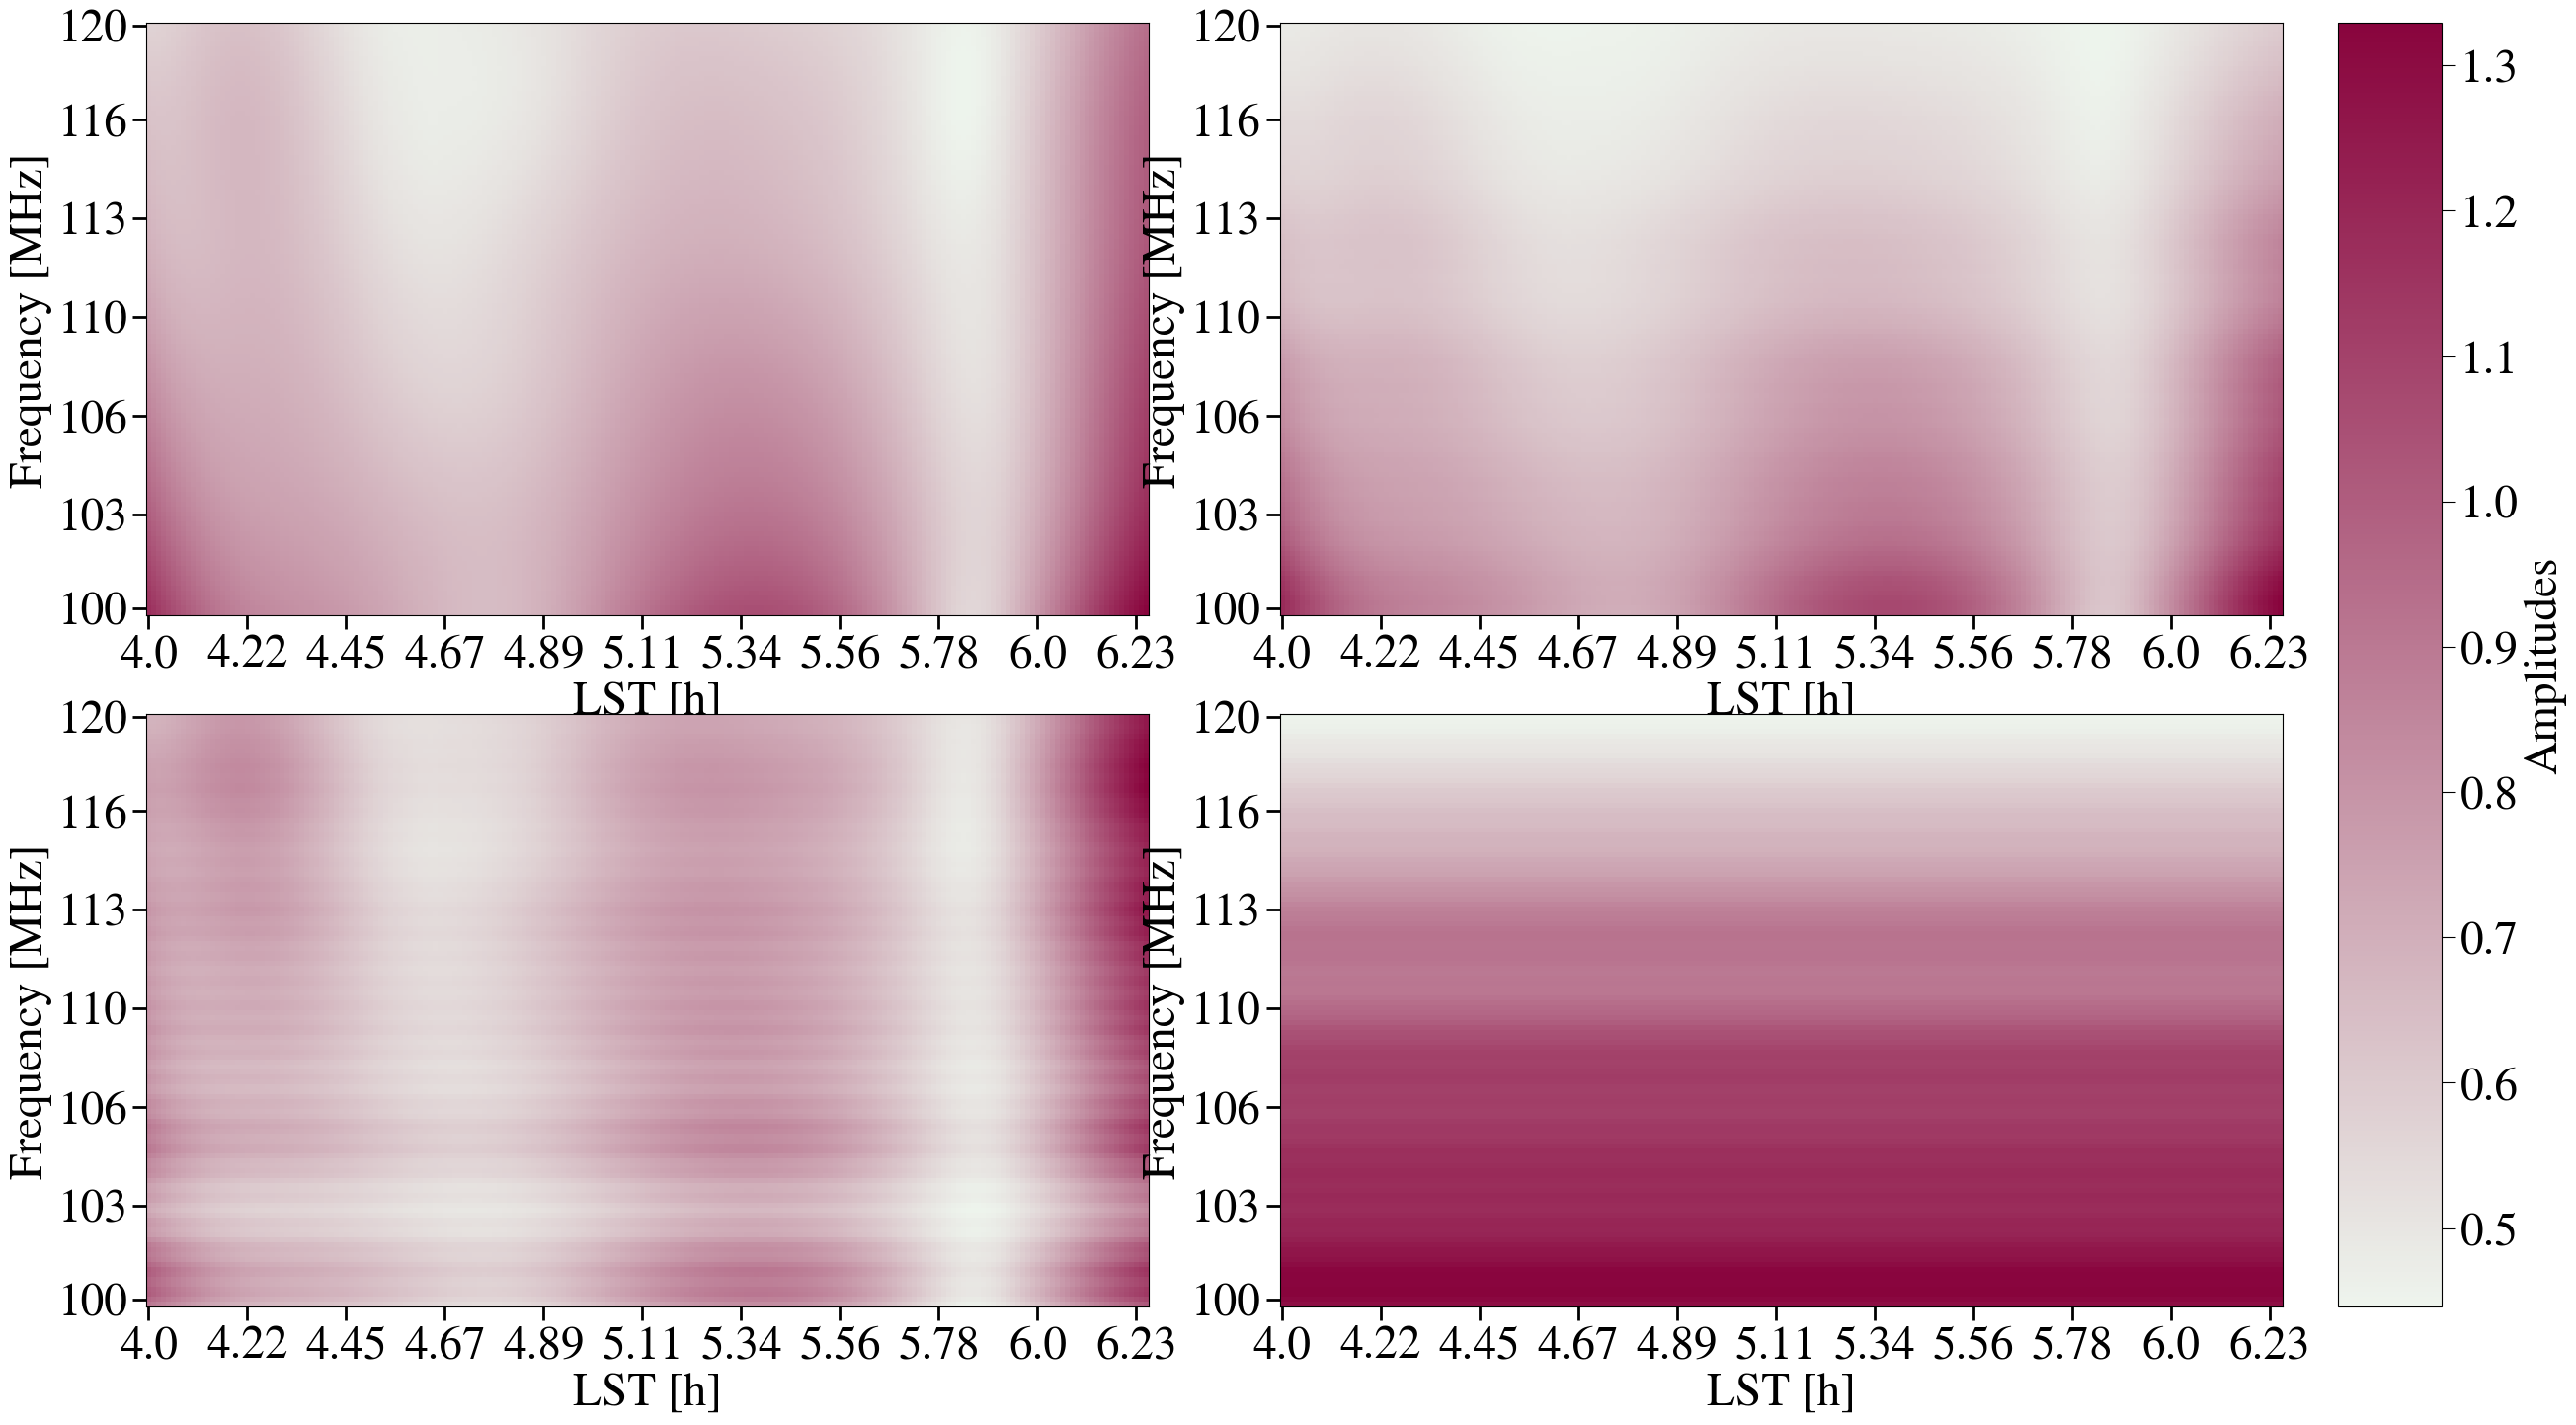

In [9]:
fig = plt.figure(figsize=(30., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.78, 0.65),
    nrows_ncols=(2, 2),
    axes_pad=1,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='all',
    aspect=False,
)
data_arr = np.array([[clean_vis, vis_corr], [vis_corr - clean_vis, vis_corr / clean_vis]])
a = 0
for i in range(2):
    for j in range(2):
        im = axs[a].imshow(np.abs(data_arr[i, j, :, :]).T, cmap=paper_map_pink, origin='lower')
        axs[a].set_ylabel('Frequency [MHz]')
        axs[a].set_xlabel('LST [h]')
        axs[a].tick_params(direction='out', length=6, width=2, colors='black', size=10)
        a += 1
cbar = axs.cbar_axes[0].colorbar(im, label='Amplitudes')
cbar.ax.tick_params(which='both', color='black', labelcolor='black', size=10)
for a in axs:
    a.set_yticks(xticklocs_full, labels=xticklabels_freqs_full)
    a.set_xticks(yticklocs_full, labels=yticklabels_times_full)
# plt.savefig(fig_dir + '/systematics_in_vis_space.pdf', bbox_inches='tight', dpi=300)

---
# Figure 3: Test case in delay–fringe-rate space

In [10]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

# Full-band true sky of this run, corrupted by the true systematic model.
# Kept separate from the single-case arrays below (`_f3` suffix) so that
# re-running this cell cannot overwrite them.
eor_true_f3  = np.load(result_dir + run_version + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true_f3   = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_f3 = eor_true_f3 + fg_true_f3
data_true_dlfr_full = dlfr(data_true_f3)


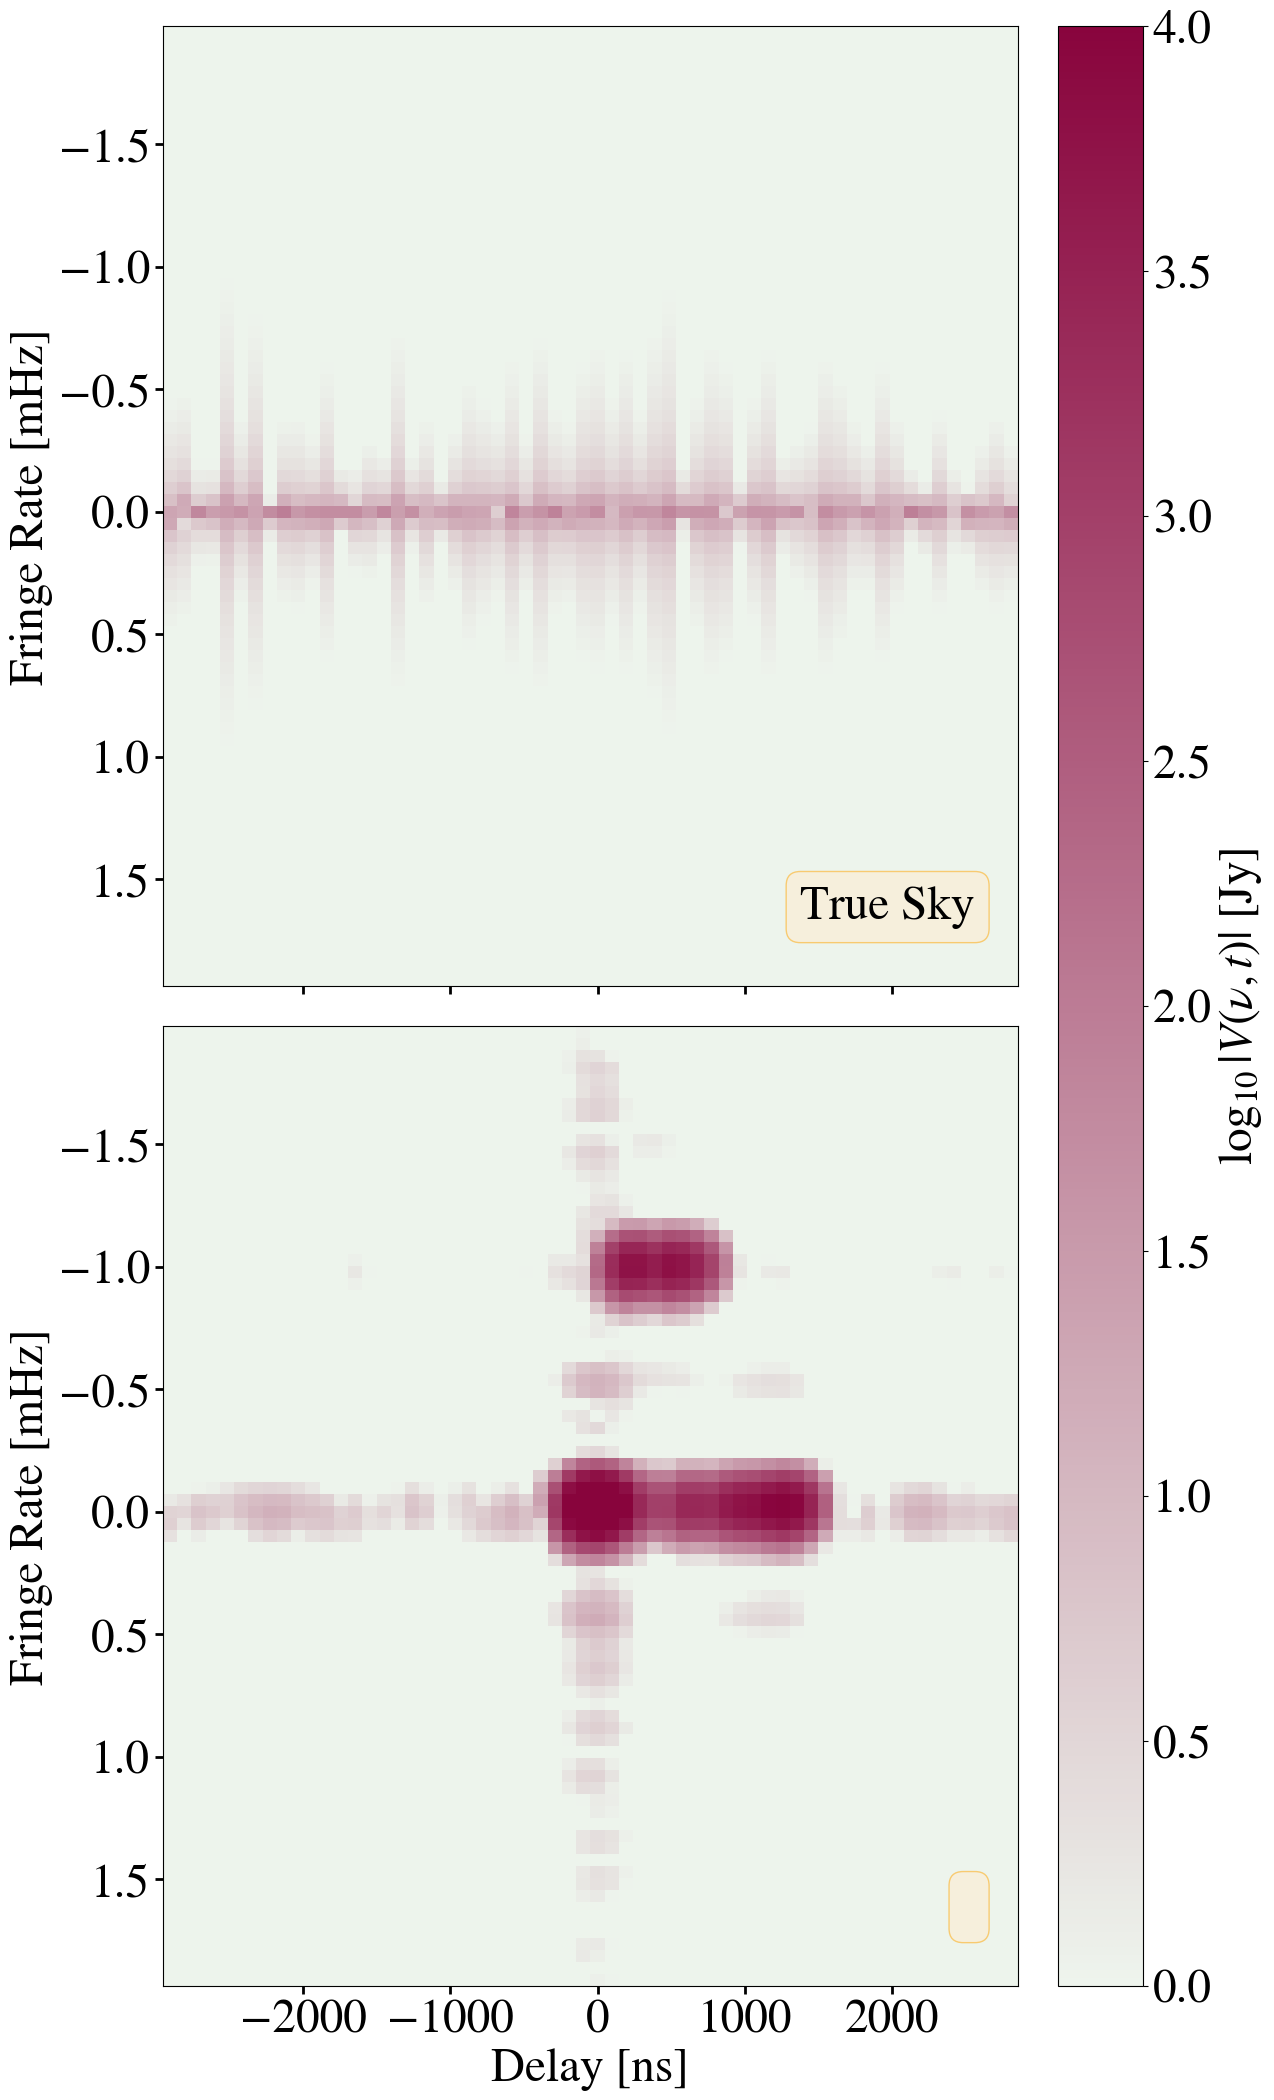

In [11]:
fig = plt.figure(figsize=(10., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 1),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls(
    eor_true_f3, freqs * 1e6, lsts, fig=fig, ax=axs[0], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all',
    baseline=None, horizon_color='magenta', colorbar_flag=False,
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

sys_model_true_f3 = (1 + sys_modes_operator @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
total_data_dlfr   = dlfr(sys_model_true_f3 * data_true_f3)
plot_op = plot_waterfalls_from_dlfr(
    total_data_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs[1], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=False,
    baseline=None, horizon_color='magenta',
)
axs[1].text(0.95, 0.07, case_label, bbox=bbox, transform=axs[1].transAxes, horizontalalignment='right')

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|V(\nu, t)|$ [Jy]')
# plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)

---
# Sample processing

Loads the Gibbs samples of `run_version` and derives every statistic used by
Figures 4-11 in a single pass over the chain.  Means, standard deviations and
the Pearson map are accumulated online (Welford), so the pass needs no array
of per-iteration DLFR maps.

In [12]:
# The Gibbs chains are read row by row rather than held in memory: at
# Niter = 100000 gcr-eor.npy alone is ~7.7 GB.
_mmap = 'r' if USE_MMAP else None

fg_true        = np.load(result_dir + run_version + '/fg_true.npy')[:Ntimes, :Nfreqs]
fgmodes        = np.load(result_dir + run_version + '/fgmodes.npy')[:, :Nfgmodes]
fg_amps_gcr    = np.load(result_dir + run_version + '/fg-amps.npy', mmap_mode=_mmap)
eor_true       = np.load(result_dir + run_version + '/eor_true.npy')[:Ntimes, :Nfreqs]
eor_gcr        = np.load(result_dir + run_version + '/gcr-eor.npy', mmap_mode=_mmap)
ps_sample      = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post        = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr      = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')[:Ntimes, :Nfreqs]
data_true      = np.load(result_dir + run_version + '/data_true.npy')[:Ntimes, :Nfreqs]

print(f'{run_version}: {b_sys_gcr.shape[0]} samples on disk, '
      f'{fgmodes.shape[1]} foreground modes used, processing {Niter} iterations')
assert fg_amps_gcr.shape[-1] >= Nfgmodes, 'fewer foreground amplitudes than Nfgmodes'
assert b_sys_gcr.shape[0] >= Niter, 'fewer samples on disk than Niter'

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# ── Static DLFR quantities ────────────────────────────────────────────────────
sky_true_dlfr       = dlfr(sky_true)
sys_model_true_dlfr = dlfr(sys_model_true)
delta_g_dlfr_true   = dlfr(delta_g_true)
data_true_dlfr      = dlfr(data_true)

# ── Per-iteration power spectra (Figure 7 needs the full distribution) ───────
ps_fg  = np.empty((Niter, Nfreqs))
ps_sys = np.empty((Niter, Nfreqs))

# ── Online accumulators for the DLFR statistics ──────────────────────────────
# Welford updates, so no [Niter, Ntimes, Nfreqs] arrays are ever allocated
# (they came to ~7.7 GB each).  `*_M2` are the sums of |x - mean|^2 behind the
# standard deviations; `*_S2` / `fg_dg_S` are the un-conjugated sums of squares
# and cross-products behind the Pearson map, matching plot_crosscor_pearson.
_z  = lambda: np.zeros((Ntimes, Nfreqs), dtype='complex')
_zr = lambda: np.zeros((Ntimes, Nfreqs))

sky_mean, sky_M2 = _z(), _zr()   # Fig 5
dg_mean,  dg_M2  = _z(), _zr()   # Fig 6
fg_mean          = _z()          # Fig 11
fg_S2, dg_S2, fg_dg_S = _z(), _z(), _z()

# ── Single pass over the Gibbs samples ───────────────────────────────────────
print('Processing samples...')
for i in tqdm(range(Niter)):
    fg_vis = (fgmodes @ fg_amps_gcr[i][:, :Nfgmodes].T).T
    dg     = (sys_modes_operator @ b_sys_gcr[i]).reshape([Nfreqs, Ntimes]).T

    ps_fg[i]  = calc_ps(fg_vis)
    ps_sys[i] = calc_ps(1 + dg)

    sky_d = dlfr(eor_gcr[i] + fg_vis)
    fg_d  = dlfr(fg_vis)
    dg_d  = dlfr(dg)

    k = i + 1
    # Sky: mean and standard deviation
    d_sky     = sky_d - sky_mean
    sky_mean += d_sky / k
    sky_M2   += (np.conj(d_sky) * (sky_d - sky_mean)).real

    # Foregrounds and systematics: means, standard deviation and cross-products.
    # The Pearson map is invariant to the constant dlfr_ones offset of the
    # systematic model, so DLFR(dg) is accumulated instead of DLFR(1 + dg).
    d_fg_old  = fg_d - fg_mean
    d_dg_old  = dg_d - dg_mean
    fg_mean  += d_fg_old / k
    dg_mean  += d_dg_old / k
    d_fg_new  = fg_d - fg_mean
    d_dg_new  = dg_d - dg_mean

    dg_M2    += (np.conj(d_dg_old) * d_dg_new).real
    fg_S2    += d_fg_old * d_fg_new
    dg_S2    += d_dg_old * d_dg_new
    fg_dg_S  += d_fg_old * d_dg_new

# ── True power spectra ────────────────────────────────────────────────────────
eor_pspec_true = calc_ps(eor_true)
fg_pspec_true  = calc_ps(fg_true)
sys_pspec_true = calc_ps(sys_model_true)
n_pspec        = calc_ps(n.T)

# ── DLFR statistics ───────────────────────────────────────────────────────────
mean_sky_dlfr       = sky_mean
std_sky_dlfr        = np.sqrt(sky_M2 / Niter)
res_sky_dlfr        = sky_true_dlfr - mean_sky_dlfr

delta_g_dlfr_mean   = dg_mean
delta_g_dlfr_std    = np.sqrt(dg_M2 / Niter)
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean   # linearity: DLFR(1+dg) = dlfr_ones + DLFR(dg)
res_sys_dlfr        = sys_model_true_dlfr - sys_model_dlfr_mean

# Pearson r between the foreground and systematic DLFR samples (Fig 11)
corr_map = fg_dg_S / np.sqrt(fg_S2 * dg_S2)

print('Done.')

caseiv: 250000 samples on disk, 10 foreground modes used, processing 250000 iterations
Processing samples...


100%|██████████| 250000/250000 [02:57<00:00, 1411.31it/s]

Done.


---
# Figure 4: Data vs sky

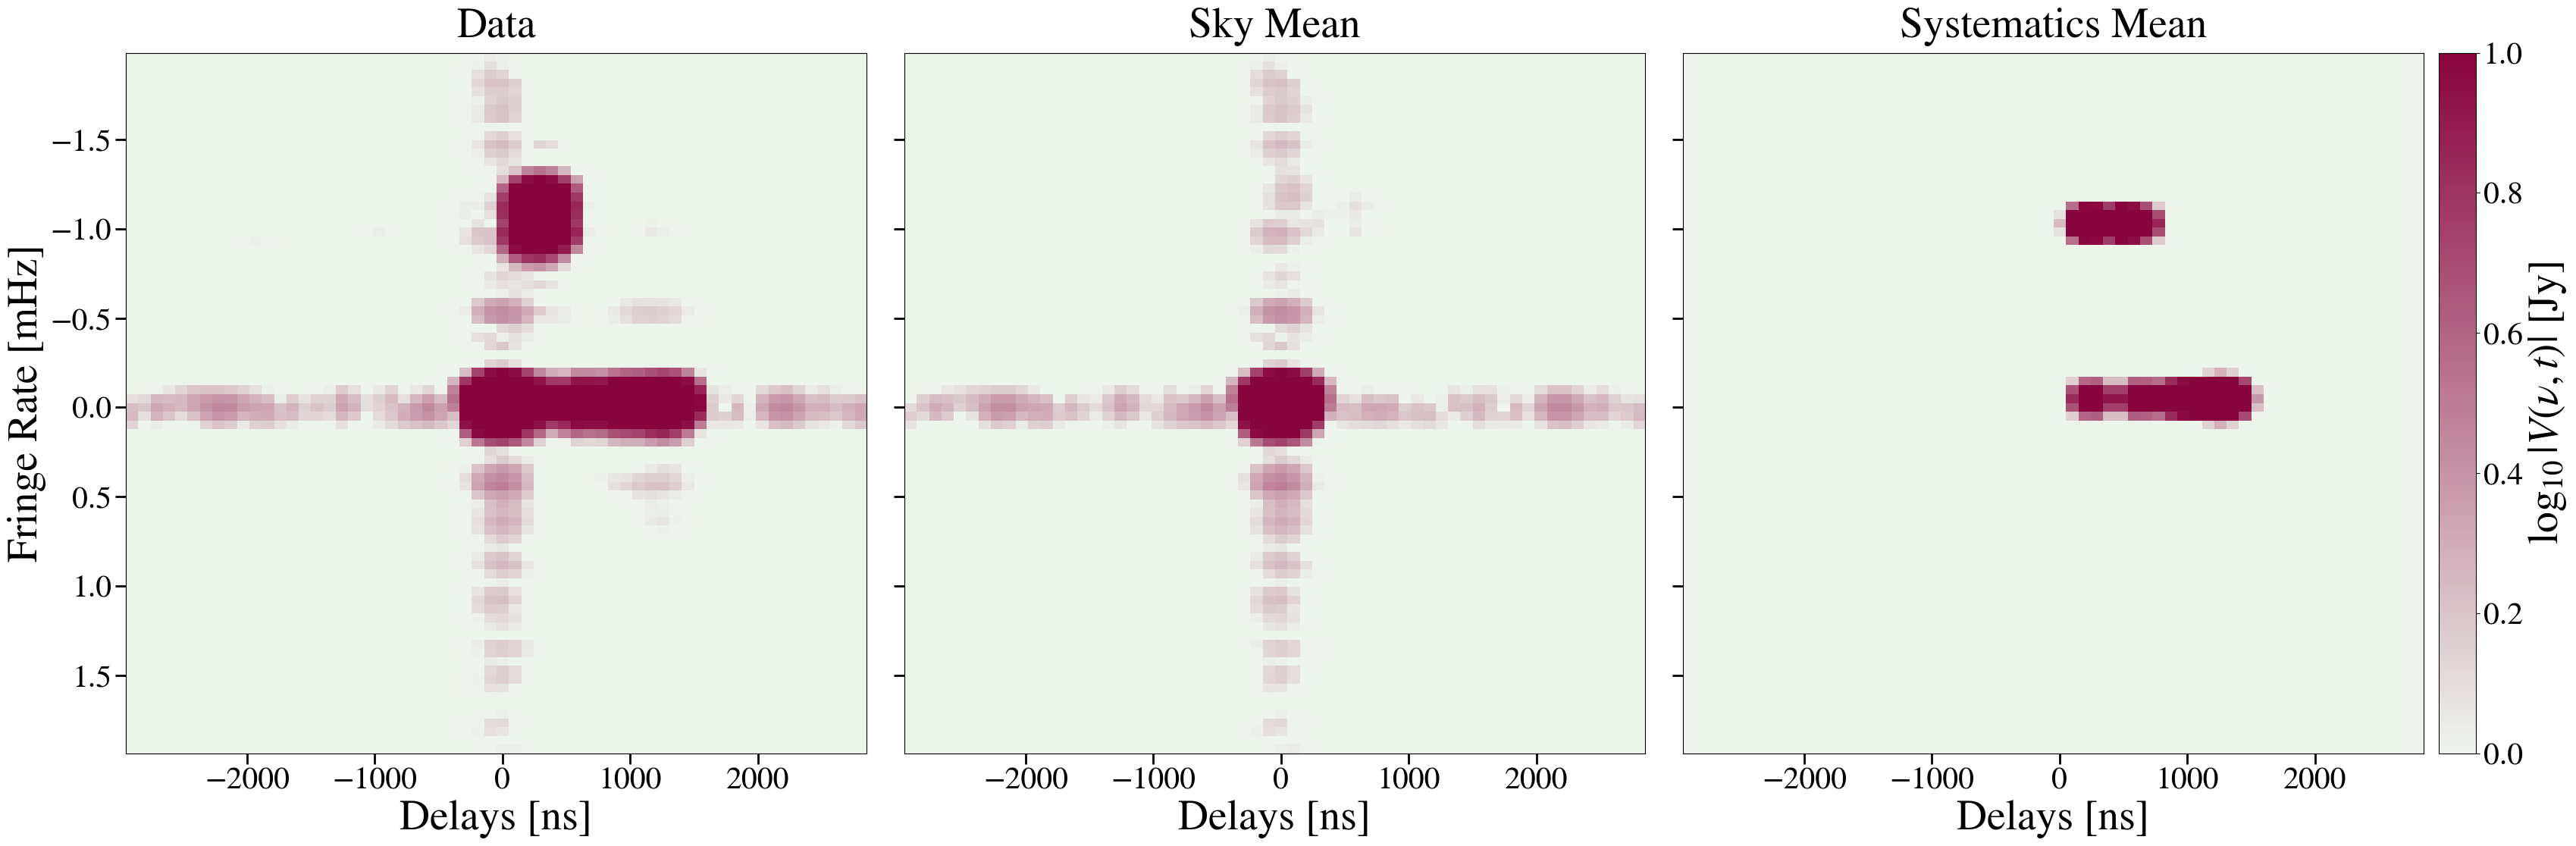

In [13]:
fig = plt.figure(figsize=(40, 12))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

im0 = plot_waterfalls_from_dlfr(
    data_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=ax[0], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)
im1 = plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=ax[1], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)
im2 = plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=ax[2], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)

fig_titles = ['Data', 'Sky Mean', 'Systematics Mean']
for i, a in enumerate(ax):
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=30)
    a.set_xlabel('Delays [ns]', fontsize=40)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=40)
    a.set_title(fig_titles[i], fontsize=40, pad=15)
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(r'$\log_{10}|V(\nu, t)|$ [Jy]', size=40)
cbar.ax.tick_params(labelsize=30)
# plt.savefig(fig_dir + '/data_vs_sky_2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5: Sky result waterfalls

True / mean / standard deviation / residuals of the sky visibilities.

Sky recovery (single case) saved.


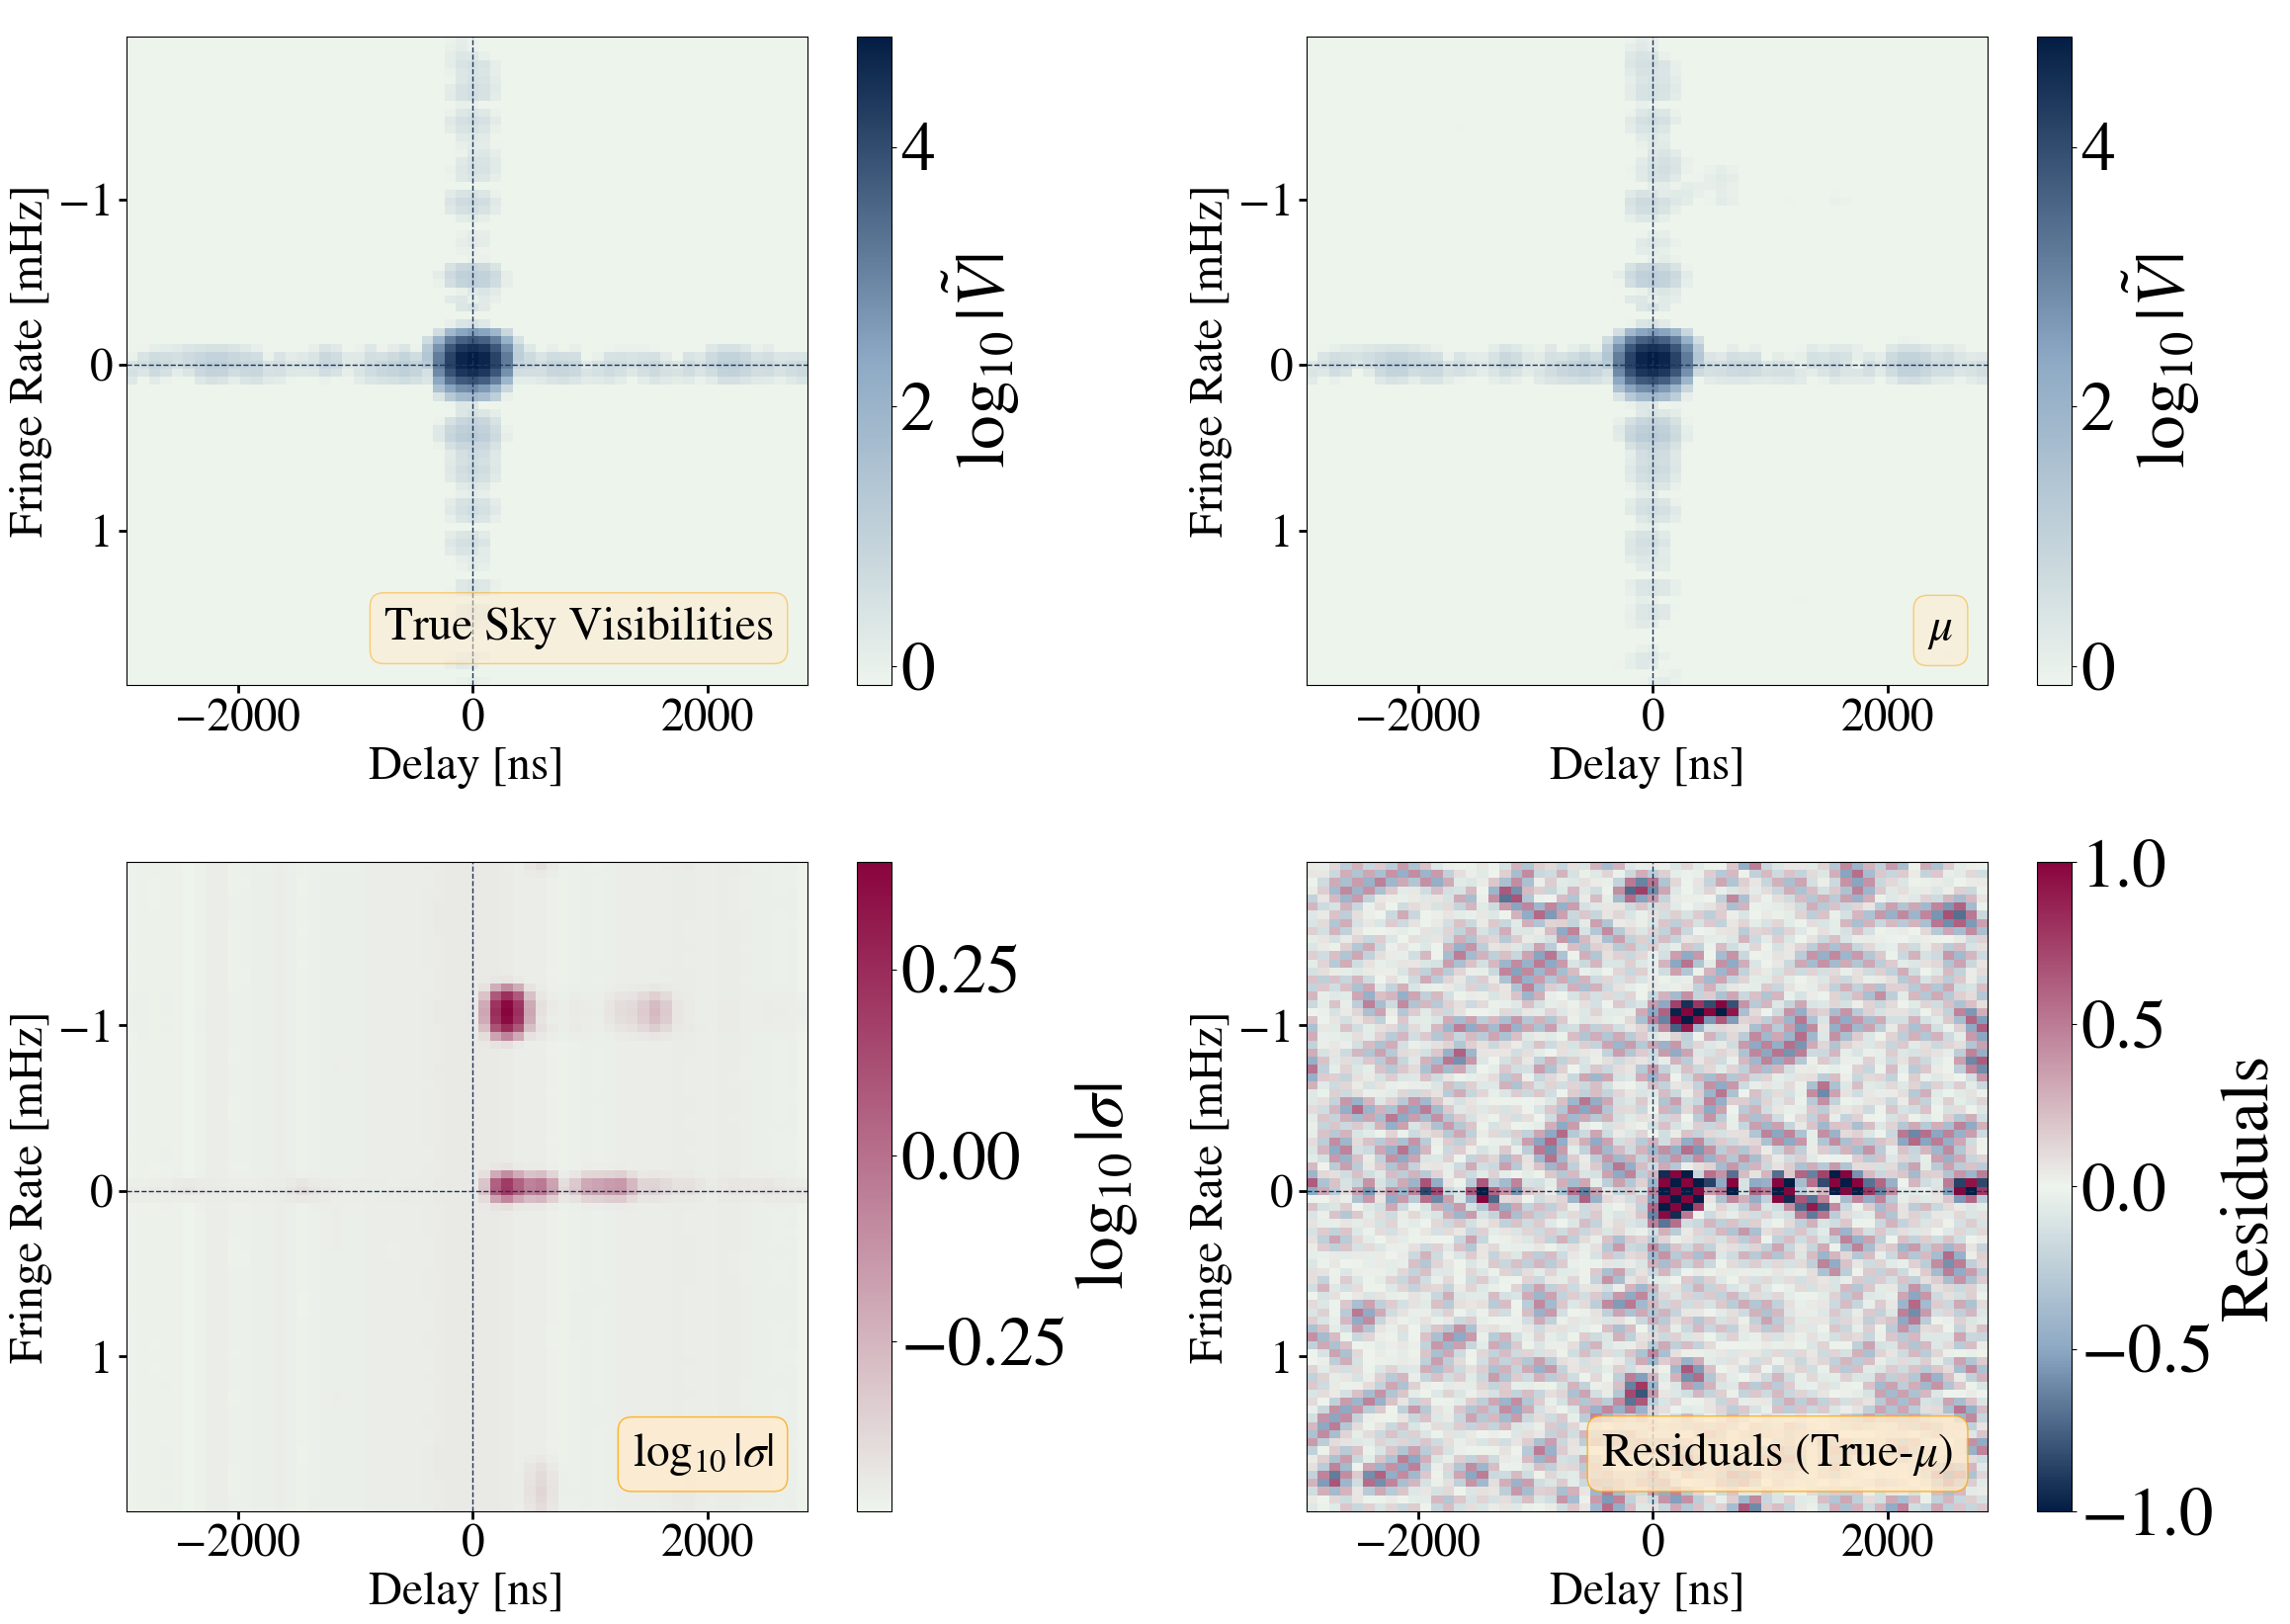

In [28]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig_single, axs = plt.subplots(2, 2, figsize=(24, 18))
axs_flat = axs.flatten()

# --- Same per-row conventions as the reference (log/abs, cmaps, vmin/vmax) ---
cmap_list   = [paper_map_blue, paper_map_blue, paper_map_pink, paper_map]
mode_list   = ['log', 'log', 'log', 'real']
vmin_list   = [None, None, None, -1]
vmax_list   = [None, None, None,  1]
cbar_labels = [
    r'$\log_{10}|\tilde{V}|$',
    r'$\log_{10}|\tilde{V}|$',
    r'$\log_{10}|\sigma|$',
    'Residuals',
]
annots = [
    'True Sky Visibilities',
    r'$\mu$',
    r'$\log_{10}|\sigma|$',
    'Residuals (True-' + r'$\mu$' + ')',
]
data_all = [sky_true_dlfr, mean_sky_dlfr, std_sky_dlfr, res_sky_dlfr]

for row in range(4):
    ax = axs_flat[row]

    im = plot_waterfalls_from_dlfr(
        data_all[row], freqs * 1e6, lsts,
        fig=fig_single, ax=ax,
        mode=mode_list[row],
        vmin=vmin_list[row], vmax=vmax_list[row],
        cmap=cmap_list[row], dynamic_range=5 if row < 2 else None,
        limit_drng='all', colorbar_flag=False,   # explicit colorbar built below instead
        baseline=None, horizon_color='magenta',
    )

    # --- Explicit colorbar, styled to match the reference exactly ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.5)
    cbar = fig_single.colorbar(im, cax=cax)
    cbar.set_label(cbar_labels[row], fontsize=50)
    cax.tick_params(labelsize=50)

    # Crosshairs — same as reference
    ax.axvline(0, color=colors[0], linestyle='--', linewidth=1)
    ax.axhline(0, color=colors[0], linestyle='--', linewidth=1)

    # Annotation box — same bbox_res-for-std-and-residual convention as reference
    bbox_use = bbox_res if row >= 2 else bbox
    ax.text(
        0.95, 0.07, annots[row], bbox=bbox_use,
        transform=ax.transAxes, ha='right',
    )

    # ax.invert_yaxis()  # flip so -ve fringe rates at the bottom

fig_single.suptitle(case_label, y=0.93)
plt.tight_layout()
plt.savefig(fig_dir + '/caseiv_sky_recovery.pdf', bbox_inches='tight', dpi=300)
print("Sky recovery (single case) saved.")

In [25]:
np.sqrt(np.mean(np.abs(res_sky_dlfr)**2))

np.float64(0.6855152018413205)

---
# Figure 6: Systematics result waterfalls

True / mean / standard deviation / residuals of the systematic model.

Text(0.5, 0.93, ' ')

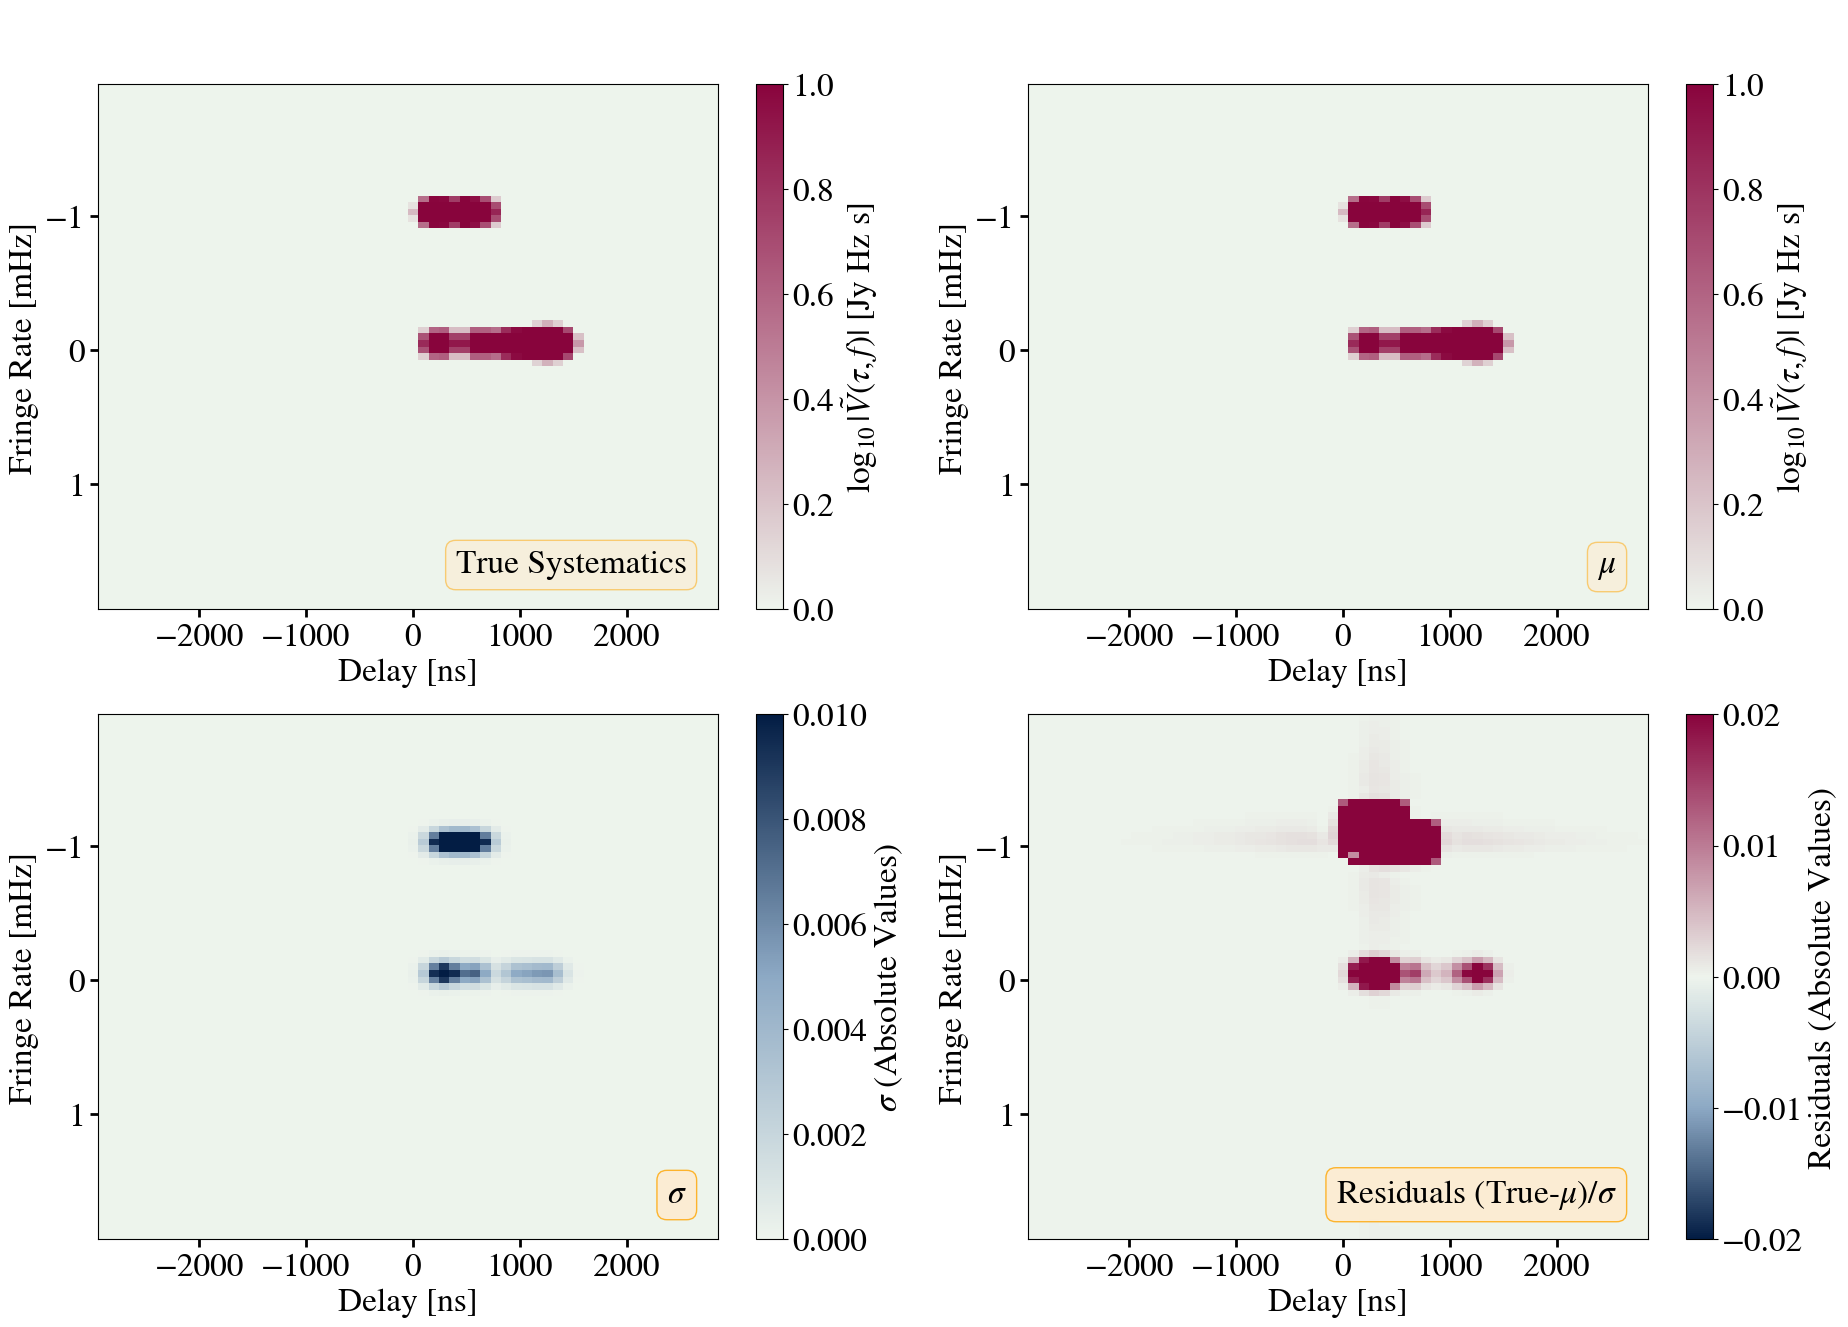

In [52]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    delta_g_dlfr_true, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Systematics', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_std, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    res_sys_dlfr/(1+delta_g_dlfr_std), freqs * 1e6, lsts,
    fig=fig, ax=axs.flatten()[3], mode='abs', vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label='Residuals (Absolute Values)',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')/'+r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')

fig.suptitle(case_label, y=0.93)
# plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figure 7: Fractional errors by component

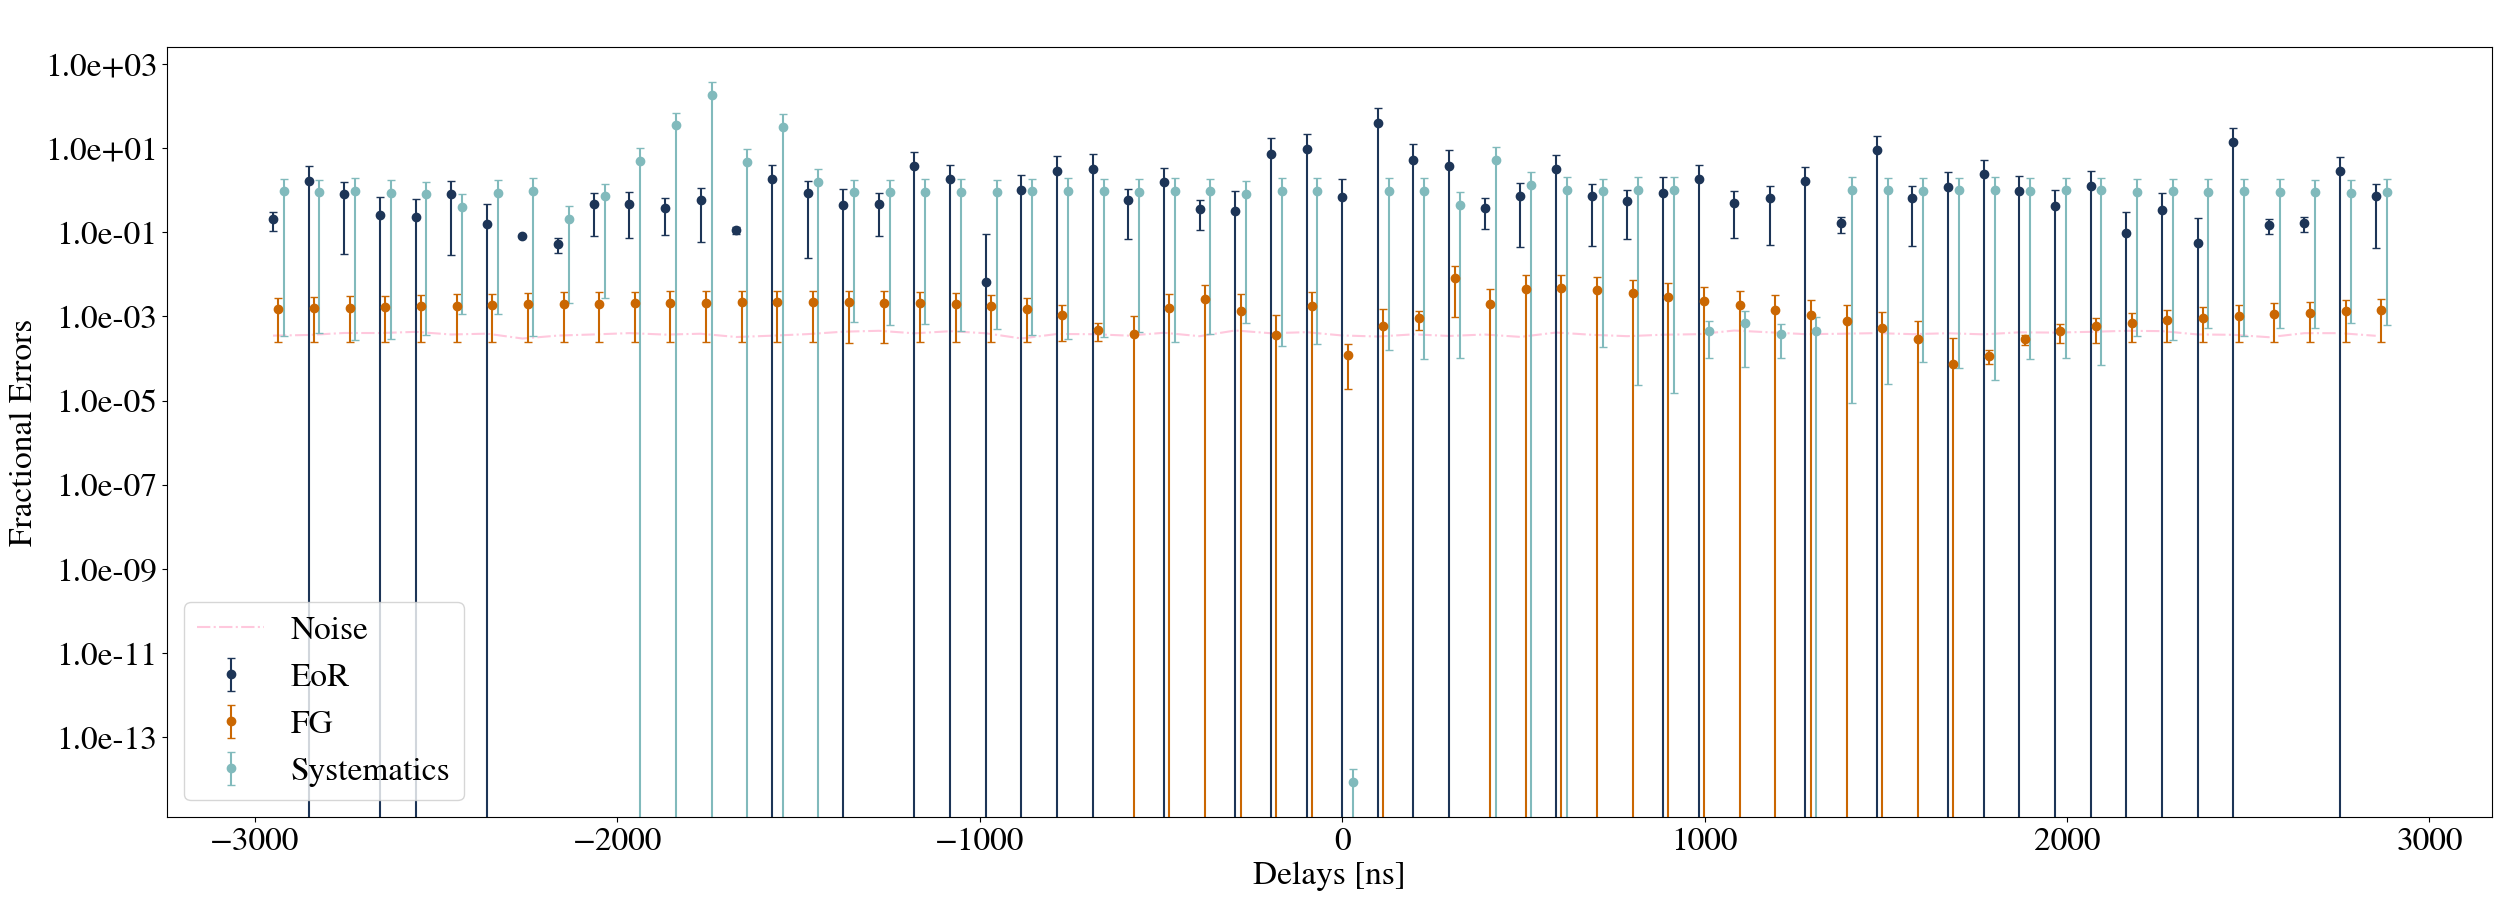

In [53]:
fig, axs = plt.subplots(1, 1, figsize=(30, 10))

data_arr_errs = [
    (eor_pspec_true - ps_sample[:Niter]) / eor_pspec_true,
    (fg_pspec_true  - ps_fg)             / fg_pspec_true,
    (sys_pspec_true - ps_sys)            / sys_pspec_true,
]
plot_arr = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['EoR', 'FG', 'Systematics', 'Noise']

rm   = np.arange(0, 15)   # delay bins masked out (foreground-dominated)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = True

axs.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], label=fig_labels_err[-1])

for i in range(3):
    pa = plot_arr[i][keep]
    da = data_arr_errs[i][:, keep]
    std  = np.std(np.abs(da), axis=0)
    errs = np.vstack((pa - std, std - pa))
    axs.errorbar(
        delays[keep].value + (i * 15), np.abs(pa),
        yerr=np.abs(errs), fmt='o', color=colors[i], label=fig_labels_err[i], capsize=3,
    )

axs.legend()
axs.set_title(case_label)
axs.set_yscale('log')
axs.set_xlabel('Delays [ns]')
axs.set_ylabel('Fractional Errors')
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
# plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)

---
# Figure 8: Corner plot of the systematic amplitudes

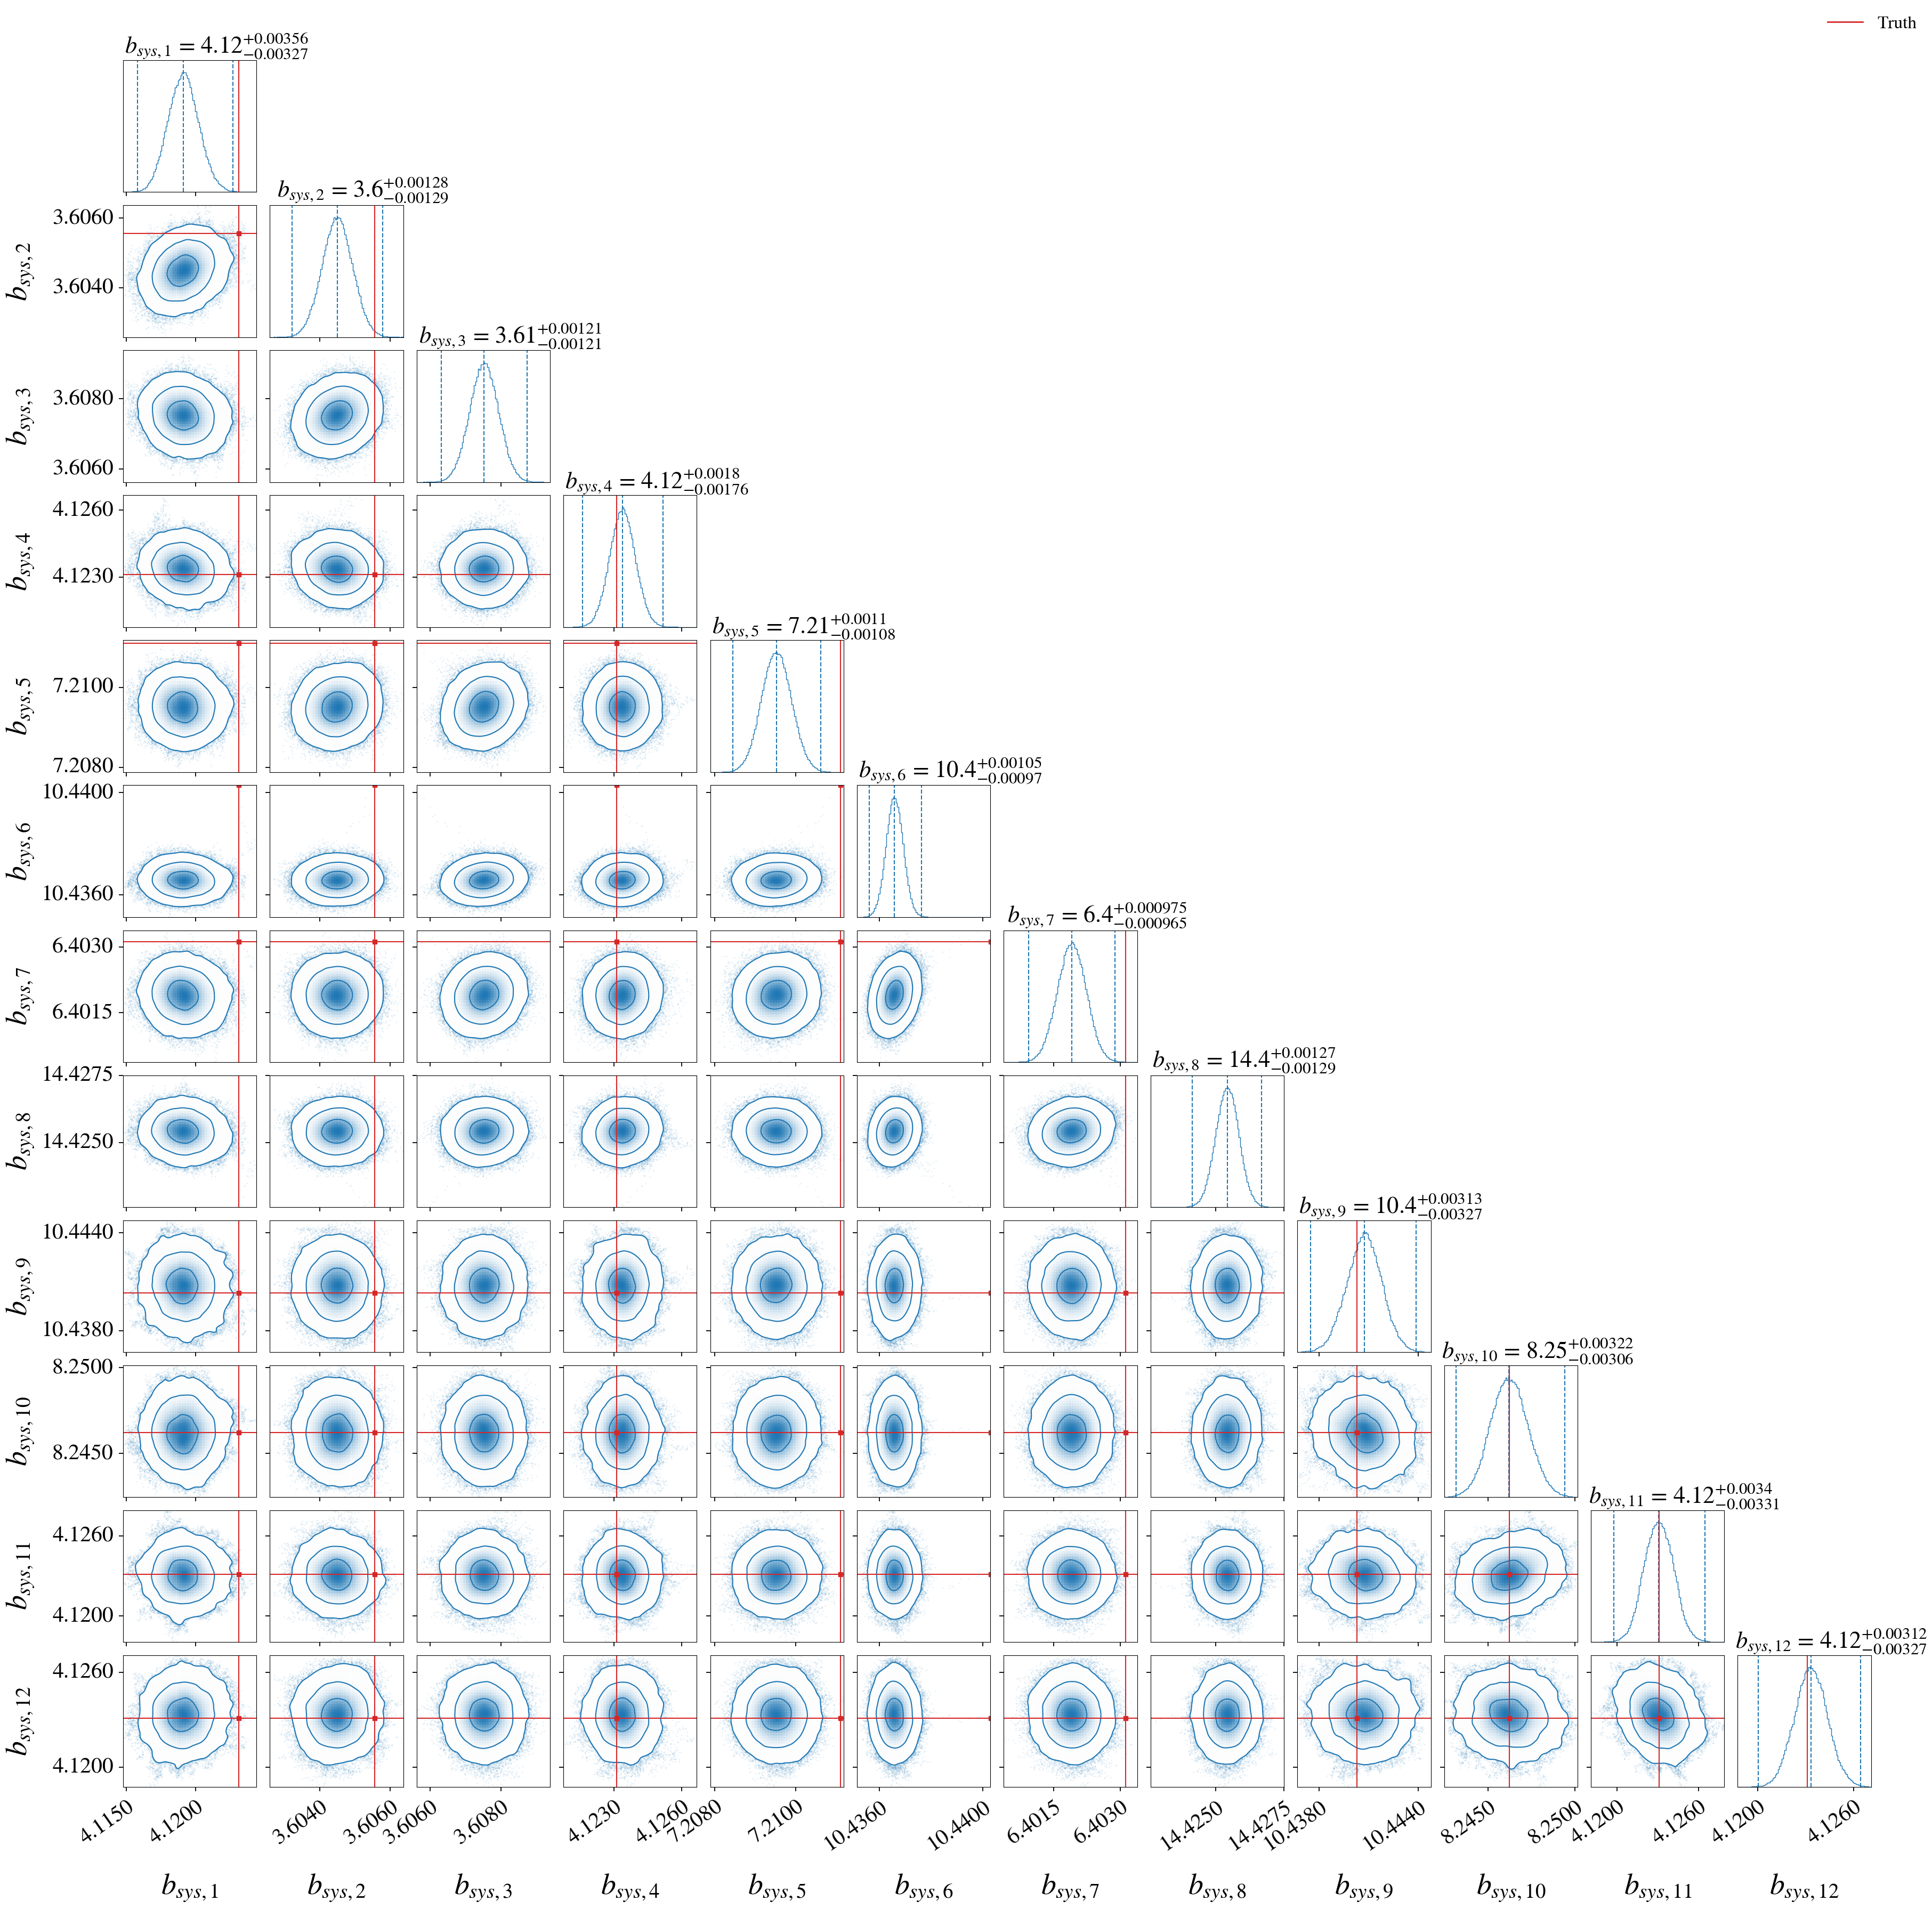

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import corner


def corner_plot(
    samples,
    labels=None,
    truths=None,
    burn=0,
    thin=1,
    fig=None,

    truths_label="Truth",

    extra_truths=None,
    extra_color="tab:green",
    extra_truths_label="Truth B",

    title=None,
    legend_loc="upper right",

    nsigma=3,

    # ---------------------------------------------------------
    # Font sizes
    # ---------------------------------------------------------
    label_fontsize=32,
    tick_fontsize=22,
    title_fontsize=22,
    legend_fontsize=24,

    # Number of candidate ticks before edge pruning
    max_n_ticks=3,

    # Large figure is necessary for 12 parameters + large fonts
    fig_size_inches=40,

    # ---------------------------------------------------------
    # Layout
    # ---------------------------------------------------------
    margin_left=0.16,
    margin_right=0.98,
    margin_bottom=0.16,
    margin_top=0.97,

    wspace=0.10,
    hspace=0.10,

    # Explicit parameter-label locations in axes coordinates.
    # These matter much more than labelpad here.
    xlabel_y=-0.52,
    ylabel_x=-0.52,

    # ---------------------------------------------------------
    # Tick formatting
    # ---------------------------------------------------------
    tick_decimals=4,
    xtick_rotation=35,
):

    # =========================================================
    # Samples
    # =========================================================
    S = samples[burn::thin]
    ndim = S.shape[1]

    # =========================================================
    # Confidence levels
    # =========================================================
    levels = [
        1.0 - np.exp(-0.5 * n**2)
        for n in range(1, nsigma + 1)
    ]

    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]

    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]

    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]

    else:
        raise ValueError(
            "nsigma must be 1, 2, or 3."
        )

    # =========================================================
    # Figure
    # =========================================================
    if fig is None:
        fig = plt.figure(
            figsize=(
                fig_size_inches,
                fig_size_inches,
            )
        )

    # =========================================================
    # Corner plot
    # =========================================================
    fig = corner.corner(
        S,

        labels=labels,

        truths=truths,
        truth_color="tab:red",

        quantiles=quantiles,
        levels=levels,

        fig=fig,

        show_titles=True,
        title_fmt=".3g",

        bins=100,
        smooth=2.0,
        color="C0",

        max_n_ticks=max_n_ticks,

        label_kwargs={
            "fontsize": label_fontsize,
        },

        title_kwargs={
            "fontsize": title_fontsize,
        },
    )

    # =========================================================
    # Optional second truth
    # =========================================================
    if extra_truths is not None:

        corner.overplot_lines(
            fig,
            extra_truths,
            color=extra_color,
            linewidth=1.6,
        )

        corner.overplot_points(
            fig,
            [extra_truths],
            color=extra_color,
            marker="s",
            ms=5,
        )

    # =========================================================
    # Axes
    # =========================================================
    axes = np.asarray(
        fig.axes[:ndim * ndim]
    ).reshape(
        ndim,
        ndim,
    )

    # =========================================================
    # Formatter factory
    # =========================================================
    def make_formatter():

        if tick_decimals is not None:

            return mticker.FormatStrFormatter(
                f"%.{tick_decimals}f"
            )

        formatter = mticker.ScalarFormatter(
            useOffset=False
        )

        formatter.set_scientific(False)

        return formatter

    # =========================================================
    # First hide ALL tick labels.
    #
    # This prevents corner's own defaults from leaking through.
    # =========================================================
    for i in range(ndim):

        for j in range(ndim):

            ax = axes[i, j]

            ax.tick_params(
                axis="x",
                labelbottom=False,
                labeltop=False,
            )

            ax.tick_params(
                axis="y",
                labelleft=False,
                labelright=False,
            )

            ax.xaxis.get_offset_text().set_visible(False)
            ax.yaxis.get_offset_text().set_visible(False)

    # =========================================================
    # Format active lower-triangle panels
    # =========================================================
    for i in range(ndim):

        for j in range(i + 1):

            ax = axes[i, j]

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=tick_fontsize,
                length=6,
                width=1.3,
                pad=7,
                direction="out",
            )

            # -------------------------------------------------
            # Interior panels:
            # keep ticks themselves if desired,
            # but do NOT display numbers.
            # -------------------------------------------------

            # =================================================
            # BOTTOM ROW: x tick numbers only
            # =================================================
            if i == ndim - 1:

                # IMPORTANT:
                # prune='both' removes ticks close to the left
                # and right boundaries of every little panel.
                #
                # This prevents:
                #
                #   4.1230 3.6000
                #
                # from colliding between neighbouring panels.
                ax.xaxis.set_major_locator(
                    mticker.MaxNLocator(
                        nbins=max_n_ticks,
                        prune="both",
                    )
                )

                ax.xaxis.set_major_formatter(
                    make_formatter()
                )

                ax.tick_params(
                    axis="x",
                    labelbottom=True,
                )

                plt.setp(
                    ax.get_xticklabels(),
                    rotation=xtick_rotation,
                    ha="right",
                    rotation_mode="anchor",
                )

            # =================================================
            # LEFT COLUMN: y tick numbers only
            # =================================================
            if j == 0 and i > 0:

                # Again prune boundary ticks.
                #
                # This keeps labels away from the horizontal
                # borders between adjacent rows.
                ax.yaxis.set_major_locator(
                    mticker.MaxNLocator(
                        nbins=max_n_ticks,
                        prune="both",
                    )
                )

                ax.yaxis.set_major_formatter(
                    make_formatter()
                )

                ax.tick_params(
                    axis="y",
                    labelleft=True,
                )

                # Horizontal y tick labels are substantially
                # easier to fit than rotated ones.
                plt.setp(
                    ax.get_yticklabels(),
                    rotation=0,
                    ha="right",
                    va="center",
                )

    # =========================================================
    # Bottom parameter labels
    # =========================================================
    for j in range(ndim):

        ax = axes[-1, j]

        ax.xaxis.label.set_fontsize(
            label_fontsize
        )

        # Explicit position rather than labelpad
        ax.xaxis.set_label_coords(
            0.5,
            xlabel_y,
        )

    # =========================================================
    # Left parameter labels
    # =========================================================
    for i in range(1, ndim):

        ax = axes[i, 0]

        ax.yaxis.label.set_fontsize(
            label_fontsize
        )

        # Explicitly place the parameter label farther left
        # than the tick numbers.
        ax.yaxis.set_label_coords(
            ylabel_x,
            0.5,
        )

    # =========================================================
    # Diagonal titles
    # =========================================================
    #
    # These strings are physically much wider than the panels,
    # so keep their font smaller than the outer parameter labels.
    #
    for i in range(ndim):

        ax = axes[i, i]

        ax.title.set_fontsize(
            title_fontsize
        )

        # Put title slightly above its own panel.
        ax.title.set_position(
            (0.7, 1.03)
        )

    # =========================================================
    # Layout
    # =========================================================
    fig.subplots_adjust(
        left=margin_left,
        right=margin_right,
        bottom=margin_bottom,
        top=margin_top,
        wspace=wspace,
        hspace=hspace,
    )

    # =========================================================
    # Legend
    # =========================================================
    legend_handles = []

    if truths is not None:

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:red",
                lw=2.0,
                label=truths_label,
            )
        )

    if extra_truths is not None:

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=extra_color,
                lw=2.0,
                label=extra_truths_label,
            )
        )

    if legend_handles:

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            frameon=False,
            fontsize=legend_fontsize,
        )

    # =========================================================
    # Overall title
    # =========================================================
    if title:

        fig.suptitle(
            title,
            y=0.995,
            fontsize=title_fontsize + 4,
        )

    return fig

fig = corner_plot(
    np.abs(b_sys_gcr),

    truths=np.abs(sys_amps_true),

    labels=[
        rf"$b_{{sys,{i}}}$"
        for i in range(1, 13)
    ],

    nsigma=3,

    fig_size_inches=40,

    label_fontsize=40,
    tick_fontsize=30,

    # Keep these smaller because the diagonal title strings
    # are much longer than an ordinary parameter label.
    title_fontsize=32,

    max_n_ticks=1,

    xlabel_y=-0.65,
    ylabel_x=-0.65,
)
plt.savefig(fig_dir + '/multi_corner_plot.pdf', bbox_inches='tight', dpi=150)

---
# Figure 8b: $\Delta b_\mathrm{sys}$ interval plot

The same posterior as the corner plot above, drawn as one row per systematic
amplitude and centred on the truth.

Each row shows the residual $\Delta b_{\mathrm{sys},i} = b_{\mathrm{sys},i} -
b^{\mathrm{true}}_{\mathrm{sys},i}$, so the dashed line through zero *is* the
truth and the axis is symmetric about it.  The **real and imaginary parts** of
each amplitude are two separate point sets on the row, offset a little above
and below its centre and coloured separately.  On each: graded bars for the
$1\sigma$, $2\sigma$ and $3\sigma$ credible intervals (the quantiles the corner
plot used), an open circle at the median, and a diamond below it for the mean
with a $\pm\sigma$ error bar.

The figure itself carries no numbers -- they come back with it as
`bsys_delta_summaries` and print below as a table (median, its $+$/$-$
deviations, mean, sigma, mean/sigma), which is what the corner plot put in its
diagonal titles.  Pass `annotate=True` to put them beside the rows instead.

Not a violin plot: nothing is smoothed, the bars are exact sample quantiles.
The chain and the credible levels are the corner plot's, so the two figures
carry the same numbers.

In [55]:

from __future__ import annotations

import argparse
import math
from dataclasses import dataclass
from typing import List, Optional, Sequence, Tuple

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ── Configuration ──────────────────────────────────────────────────────────

# Notebook palette (`colors` in the plot-specifications cell).
PAPER_COLORS: List[str] = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ffc8dd']

# Line widths of the graded interval bars, thickest (1 sigma) first.
BAR_WIDTHS: Tuple[float, ...] = (11.0, 5.5, 2.2)

# Neutral colour of the shape entries in the key (bar widths, markers): they
# describe every component rather than one of them.
NEUTRAL_COLOR: str = '#555555'

# Vertical offset of the mean +/- sigma error bar below its interval bar, as a
# fraction of the space one point set owns.
MEAN_OFFSET: float = 0.42

# Vertical separation of the components of one parameter, as a fraction of the
# row height.
COMPONENT_GAP: float = 0.42

# Fraction of the half-range left as padding at each end of the x axis.
XPAD: float = 0.12

# The reductions a chain can be drawn through.
COMPONENT_FUNCS = {
    'real': np.real,
    'imag': np.imag,
    'abs': np.abs,
    'value': lambda x: x,      # a chain that is already real
}

# How each reduction is named in the key.
COMPONENT_LABELS = {
    'real': r'$\mathrm{Re}$',
    'imag': r'$\mathrm{Im}$',
    'abs': r'$|\cdot|$',
    'value': '',
}


# ── Statistics ─────────────────────────────────────────────────────────────

@dataclass
class DeltaSummary:
    """Posterior summary of one systematic amplitude residual.

    Attributes
    ----------
    label : str
        Parameter label, used on the y axis of the figure.
    truth : float
        True value the residual is measured from.
    mean : float
        Posterior mean of ``delta b_sys``.
    median : float
        Posterior median of ``delta b_sys``.
    std : float
        Posterior standard deviation (sigma).
    lower : list of float
        Lower credible bounds of ``delta b_sys``, 1 sigma first.
    upper : list of float
        Upper credible bounds of ``delta b_sys``, 1 sigma first.
    nsamples : int
        Number of samples the summary was computed from.
    component : str
        Which reduction of the chain this is -- ``'real'``, ``'imag'``,
        ``'abs'``, or ``'value'`` for a chain that was already real.
    """

    label: str
    truth: float
    mean: float
    median: float
    std: float
    lower: List[float]
    upper: List[float]
    nsamples: int
    component: str = 'value'

    @property
    def minus(self) -> List[float]:
        """Distances from the median down to each lower bound (positive)."""
        return [self.median - lo for lo in self.lower]

    @property
    def plus(self) -> List[float]:
        """Distances from the median up to each upper bound (positive)."""
        return [hi - self.median for hi in self.upper]

    @property
    def pull(self) -> float:
        """Mean residual in units of sigma, ``mean / std`` (0 if sigma is 0)."""
        return self.mean / self.std if self.std > 0. else 0.


def sigma_quantiles(nsigma: int) -> List[Tuple[float, float]]:
    """Two-sided Gaussian quantile pairs for 1 .. ``nsigma`` sigma.

    Parameters
    ----------
    nsigma : int
        Highest sigma level, 1, 2 or 3, as in the notebook's ``corner_plot``.

    Returns
    -------
    list of tuple of float
        ``(lower, upper)`` quantiles, 1 sigma first, e.g. ``(0.15865,
        0.84135)`` for one sigma.

    Raises
    ------
    ValueError
        If ``nsigma`` is not 1, 2 or 3.
    """
    if nsigma not in (1, 2, 3):
        raise ValueError('nsigma must be 1, 2, or 3.')

    pairs = []
    for k in range(1, nsigma + 1):
        upper = 0.5 * (1. + math.erf(k / math.sqrt(2.)))
        pairs.append((1. - upper, upper))
    return pairs


def component_chains(
    samples: np.ndarray,
    truths: Sequence[complex],
    components: Optional[Sequence[str]] = None,
) -> List[Tuple[str, np.ndarray, np.ndarray]]:
    """Split a chain into the real chains that will be drawn.

    Parameters
    ----------
    samples : numpy.ndarray
        Chain of shape ``(nsamples, ndim)``, complex or real.
    truths : sequence of complex
        The ``ndim`` true amplitudes, in the same form as ``samples``.
    components : sequence of str, optional
        Reductions to draw, from `COMPONENT_FUNCS`.  Default:
        ``('real', 'imag')`` for a complex chain, ``('value',)`` for a real
        one.

    Returns
    -------
    list of tuple
        ``(component, samples, truths)``, one entry per component, with real
        arrays.

    Raises
    ------
    ValueError
        If ``samples`` is not 2D, ``truths`` does not match its second axis,
        or a component name is not one of `COMPONENT_FUNCS`.

    Notes
    -----
    The reduction is applied to the samples and to the truths separately, and
    the residual is taken afterwards -- the same thing for the linear parts,
    and for ``'abs'`` it is what the corner plot does.
    """
    S = np.asarray(samples)
    t = np.asarray(truths)

    if S.ndim != 2:
        raise ValueError(f'samples must be 2D (nsamples, ndim), got {S.shape}')
    if t.shape != (S.shape[1],):
        raise ValueError(f'truths has shape {t.shape}, expected {(S.shape[1],)}')

    if components is None:
        components = ('real', 'imag') if np.iscomplexobj(S) else ('value',)
    components = list(components)

    if not components:
        raise ValueError('components is empty')
    unknown = [c for c in components if c not in COMPONENT_FUNCS]
    if unknown:
        raise ValueError(f'unknown components {unknown}; choose from '
                         f'{sorted(COMPONENT_FUNCS)}')

    chains = []
    for name in components:
        reduce = COMPONENT_FUNCS[name]
        chains.append((name,
                       np.asarray(reduce(S), dtype=float),
                       np.asarray(reduce(t), dtype=float)))
    return chains


def delta_samples(
    samples: np.ndarray,
    truths: Sequence[float],
    burn: int = 0,
    thin: int = 1,
) -> np.ndarray:
    """Residual chain ``samples - truths``, after burn-in and thinning.

    Parameters
    ----------
    samples : numpy.ndarray
        Real samples of shape ``(nsamples, ndim)``.  Complex chains must be
        reduced first (``np.abs``, ``np.real``, ...), exactly as they are for
        the corner plot.
    truths : sequence of float
        The ``ndim`` true values, reduced the same way as ``samples``.
    burn : int, optional
        Number of leading samples to discard.  Default 0, matching the corner
        plot.
    thin : int, optional
        Keep every ``thin``-th sample.  Default 1.

    Returns
    -------
    numpy.ndarray
        Residuals of shape ``(nkept, ndim)``.

    Raises
    ------
    ValueError
        If ``samples`` is not 2D, if ``truths`` does not match its second
        axis, if ``thin`` is not positive, or if burn-in leaves no samples.
    TypeError
        If ``samples`` or ``truths`` are complex.
    """
    S = np.asarray(samples)
    t = np.asarray(truths)

    if S.ndim != 2:
        raise ValueError(f'samples must be 2D (nsamples, ndim), got {S.shape}')
    if np.iscomplexobj(S) or np.iscomplexobj(t):
        raise TypeError('samples and truths must be real; reduce the complex '
                        'chain first, e.g. np.abs(b_sys_gcr).')
    if t.shape != (S.shape[1],):
        raise ValueError(f'truths has shape {t.shape}, expected {(S.shape[1],)}')
    if thin < 1:
        raise ValueError(f'thin must be >= 1, got {thin}')
    if burn < 0:
        raise ValueError(f'burn must be >= 0, got {burn}')

    kept = S[burn::thin]
    if kept.shape[0] == 0:
        raise ValueError(f'burn={burn}, thin={thin} leave no samples of '
                         f'{S.shape[0]}')

    return kept - t[None, :]


def summarise_delta(
    deltas: np.ndarray,
    labels: Optional[Sequence[str]] = None,
    truths: Optional[Sequence[float]] = None,
    nsigma: int = 3,
    component: str = 'value',
) -> List[DeltaSummary]:
    """Summarise a residual chain parameter by parameter.

    Parameters
    ----------
    deltas : numpy.ndarray
        Residuals of shape ``(nsamples, ndim)``, from `delta_samples`.
    labels : sequence of str, optional
        Parameter labels.  Default ``r'$b_{sys,i}$'`` for ``i = 1 .. ndim``.
    truths : sequence of float, optional
        True values, carried through into the summaries.  Default zeros.
    nsigma : int, optional
        Highest sigma level summarised.  Default 3, as in the corner plot.
    component : str, optional
        Reduction these residuals came through, recorded on each summary.
        Default ``'value'``.

    Returns
    -------
    list of DeltaSummary
        One summary per parameter, in column order.

    Raises
    ------
    ValueError
        If ``deltas`` is not 2D or ``labels`` / ``truths`` have the wrong
        length.
    """
    D = np.asarray(deltas)
    if D.ndim != 2:
        raise ValueError(f'deltas must be 2D (nsamples, ndim), got {D.shape}')

    ndim = D.shape[1]
    names = list(labels) if labels is not None else default_labels(ndim)
    if len(names) != ndim:
        raise ValueError(f'got {len(names)} labels for {ndim} parameters')

    true_vals = np.zeros(ndim) if truths is None else np.asarray(truths, float)
    if true_vals.shape != (ndim,):
        raise ValueError(f'got {true_vals.shape} truths for {ndim} parameters')

    quantiles = sigma_quantiles(nsigma)
    flat = [q for pair in quantiles for q in pair]
    bounds = np.percentile(D, [100. * q for q in flat], axis=0)

    summaries = []
    for i in range(ndim):
        summaries.append(DeltaSummary(
            label=names[i],
            truth=float(true_vals[i]),
            mean=float(D[:, i].mean()),
            median=float(np.median(D[:, i])),
            std=float(D[:, i].std()),
            lower=[float(bounds[2 * k, i]) for k in range(len(quantiles))],
            upper=[float(bounds[2 * k + 1, i]) for k in range(len(quantiles))],
            nsamples=int(D.shape[0]),
            component=component,
        ))
    return summaries


def default_labels(ndim: int) -> List[str]:
    """``[r'$b_{sys,1}$', ...]`` for ``ndim`` parameters.

    Parameters
    ----------
    ndim : int
        Number of systematic amplitudes.

    Returns
    -------
    list of str
        Math-mode labels, numbered from 1.
    """
    return [rf'$b_{{sys,{i}}}$' for i in range(1, ndim + 1)]


def common_exponent(value: float, threshold: int = 3) -> int:
    """Power of ten worth factoring out of a group of numbers.

    Parameters
    ----------
    value : float
        Largest magnitude of the group that will be written together.
    threshold : int, optional
        Smallest ``|exponent|`` worth factoring out.  Default 3, so numbers
        between 0.001 and 1000 keep their plain decimal form.

    Returns
    -------
    int
        Exponent to factor out; 0 means "write the numbers as they are".
    """
    if not np.isfinite(value) or value == 0.:
        return 0

    exponent = int(math.floor(math.log10(abs(value))))
    return exponent if abs(exponent) >= threshold else 0


def decimals_for(value: float, sig: int = 3) -> int:
    """Decimal places giving ``value`` ``sig`` significant digits.

    Parameters
    ----------
    value : float
        Reference value, usually the smallest quantity on the line.
    sig : int, optional
        Significant digits wanted.  Default 3.

    Returns
    -------
    int
        Number of decimal places, never negative.
    """
    if not np.isfinite(value) or value == 0.:
        return sig - 1

    return max(0, sig - 1 - int(math.floor(math.log10(abs(value)))))


def _fixed_decimals(reference: float, centre: float, sig: int) -> int:
    """Decimals set by ``reference``, widened if ``centre`` would round to 0.

    Parameters
    ----------
    reference : float
        Quantity that sets the precision (a deviation or sigma).
    centre : float
        Quantity that must not be printed as a bare zero (a median or mean).
    sig : int
        Significant digits wanted for ``reference``.

    Returns
    -------
    int
        Decimal places to use for every number on the line.
    """
    decimals = decimals_for(reference, sig)

    if centre != 0. and round(centre, decimals) == 0.:
        # Give the centre one significant digit rather than print '0.000'.
        decimals = min(decimals_for(centre, 1), decimals + 3)

    return decimals


def _times_power(exponent: int) -> str:
    """``\\times 10^{e}`` for a non-zero exponent, empty string otherwise.

    Parameters
    ----------
    exponent : int
        Factored-out power of ten.

    Returns
    -------
    str
        Math-mode fragment, without surrounding ``$``.
    """
    return '' if exponent == 0 else rf'\times 10^{{{exponent}}}'


def format_triplet(
    centre: float,
    plus: float,
    minus: float,
    sig: int = 3,
    exponent: Optional[int] = None,
) -> str:
    """``centre +plus -minus`` as math-text, with a shared power of ten.

    Parameters
    ----------
    centre : float
        Central value (the median).
    plus, minus : float
        Positive distances up to the upper and down to the lower bound.
    sig : int, optional
        Significant digits of the deviations.  Default 3.
    exponent : int, optional
        Power of ten to factor out.  Default: chosen from the deviations by
        `common_exponent`.  Pass one to keep several rows consistent.

    Returns
    -------
    str
        Math-mode body, e.g. ``0.0000^{+0.0124}_{-0.0121}``, or
        ``\\left(...\\right)\\times 10^{-6}`` when everything is tiny.

    Notes
    -----
    All three numbers share one power of ten so that a mantissa's own
    exponent never collides with the ``+``/``-`` superscripts, which
    matplotlib's math-text renders as a second superscript.
    """
    reference = max(abs(plus), abs(minus)) or abs(centre) or 1.
    if exponent is None:
        exponent = common_exponent(reference)
    scale = 10. ** exponent

    decimals = _fixed_decimals(reference / scale, centre / scale, sig)
    body = (f'{centre / scale:.{decimals}f}'
            f'^{{+{plus / scale:.{decimals}f}}}'
            f'_{{-{minus / scale:.{decimals}f}}}')

    if exponent == 0:
        return body
    return rf'\left({body}\right){_times_power(exponent)}'


def format_mean_sigma(
    mean: float,
    std: float,
    sig: int = 3,
    exponent: Optional[int] = None,
) -> str:
    """``\\mu = ..., \\sigma = ...`` as math-text, with a shared power of ten.

    Parameters
    ----------
    mean : float
        Posterior mean of the residual.
    std : float
        Posterior standard deviation.
    sig : int, optional
        Significant digits of sigma.  Default 3.
    exponent : int, optional
        Power of ten to factor out.  Default: chosen from sigma by
        `common_exponent`.

    Returns
    -------
    str
        Math-mode body, without surrounding ``$``.
    """
    reference = abs(std) or abs(mean) or 1.
    if exponent is None:
        exponent = common_exponent(reference)
    scale = 10. ** exponent

    decimals = _fixed_decimals(reference / scale, mean / scale, sig)
    power = _times_power(exponent)

    return (rf'\mu = {mean / scale:.{decimals}f}{power}, \ '
            rf'\sigma = {std / scale:.{decimals}f}{power}')


def shared_exponent(
    summaries: Sequence[DeltaSummary],
    nsigma: Optional[int] = None,
    max_spread: int = 2,
) -> Optional[int]:
    """Power of ten that suits every row, or None if the rows are too unalike.

    Parameters
    ----------
    summaries : sequence of DeltaSummary
        Parameter summaries, one per row of the figure.
    nsigma : int, optional
        Sigma level whose deviations set the magnitudes.  Default: the highest
        level held by the summaries.
    max_spread : int, optional
        Largest range of magnitudes, in decades, still worth writing on one
        common scale.  Default 2.

    Returns
    -------
    int or None
        Exponent to factor out of every row (0 meaning "plain decimals"), or
        None when the rows span more than ``max_spread`` decades and are
        better formatted one by one.
    """
    exponents = []
    for summary in summaries:
        k = (len(summary.lower) if nsigma is None else nsigma) - 1
        reference = (max(abs(summary.plus[k]), abs(summary.minus[k]))
                     or abs(summary.median) or abs(summary.std))
        if reference > 0. and np.isfinite(reference):
            exponents.append(int(math.floor(math.log10(reference))))

    if not exponents:
        return 0
    if max(exponents) - min(exponents) > max_spread:
        return None

    return common_exponent(10. ** max(exponents))


def format_summary(
    summary: DeltaSummary,
    sig: int = 3,
    nsigma: Optional[int] = None,
    exponent: Optional[int] = None,
) -> str:
    """Two-line annotation carrying the corner plot's diagonal-title numbers.

    Parameters
    ----------
    summary : DeltaSummary
        Summary of one parameter.
    sig : int, optional
        Significant digits for every number.  Default 3, matching the corner
        plot's ``title_fmt='.3g'``.
    nsigma : int, optional
        Sigma level whose deviations are quoted.  Default: the highest level
        held by ``summary``.
    exponent : int, optional
        Power of ten factored out of both lines.  Default: chosen per line.
        `shared_exponent` supplies one that suits every row of a figure.

    Returns
    -------
    str
        ``median +hi -lo`` on the first line; mean, sigma and the mean in
        units of sigma on the second, as a matplotlib math-text string.

    Raises
    ------
    ValueError
        If ``nsigma`` exceeds the levels held by ``summary``.
    """
    level = len(summary.lower) if nsigma is None else nsigma
    if not 1 <= level <= len(summary.lower):
        raise ValueError(f'summary holds {len(summary.lower)} sigma levels, '
                         f'asked for {level}')

    k = level - 1
    median = format_triplet(summary.median, summary.plus[k], summary.minus[k],
                            sig=sig, exponent=exponent)
    mean_sigma = format_mean_sigma(summary.mean, summary.std, sig=sig,
                                   exponent=exponent)

    return (rf'$\Delta = {median}$   (${level}\sigma$)'
            '\n'
            rf'${mean_sigma}$, '
            rf'$\mu/\sigma = {summary.pull:.2f}$')


# ── Plot ───────────────────────────────────────────────────────────────────

def _scale_factors(
    summaries: Sequence[DeltaSummary],
    units: str,
) -> np.ndarray:
    """Per-parameter divisor turning residuals into the requested units.

    Parameters
    ----------
    summaries : sequence of DeltaSummary
        Parameter summaries.
    units : {'absolute', 'sigma'}
        ``'absolute'`` leaves the residuals alone; ``'sigma'`` divides each by
        its own posterior standard deviation.

    Returns
    -------
    numpy.ndarray
        One positive divisor per parameter.

    Raises
    ------
    ValueError
        If ``units`` is not one of the two accepted values.
    """
    if units == 'absolute':
        return np.ones(len(summaries))
    if units == 'sigma':
        return np.array([s.std if s.std > 0. else 1. for s in summaries])
    raise ValueError(f"units must be 'absolute' or 'sigma', got {units!r}")


def _draw_row(
    ax: plt.Axes,
    y: float,
    summary: DeltaSummary,
    scale: float,
    color: str,
    bar_widths: Sequence[float],
    marker_size: float,
    mean_offset: float,
) -> None:
    """Draw the interval bars and markers of one point set onto ``ax``.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to draw into.
    y : float
        Centre of this point set, in data coordinates.
    summary : DeltaSummary
        Summary of the parameter component drawn here.
    scale : float
        Divisor applied to every abscissa (see `_scale_factors`).
    color : str
        Colour of the bars and both markers; one colour per component.
    bar_widths : sequence of float
        Line widths of the interval bars, thickest (1 sigma) first.
    marker_size : float
        Size of the median marker.
    mean_offset : float
        Vertical offset of the mean error bar below the interval bar.
    """
    nlevels = len(summary.lower)

    # Widest interval first, so the thicker inner bars are drawn on top.
    for k in reversed(range(nlevels)):
        width = bar_widths[min(k, len(bar_widths) - 1)]
        ax.plot(
            [summary.lower[k] / scale, summary.upper[k] / scale],
            [y, y],
            color=color,
            linewidth=width,
            alpha=1.0 - 0.15 * k,
            solid_capstyle='butt',
            zorder=3 + k,
        )

    # Mean +/- sigma, offset below the interval bar so the two do not overlap.
    ax.errorbar(
        summary.mean / scale,
        y + mean_offset,
        xerr=summary.std / scale,
        fmt='D',
        markersize=marker_size * 0.55,
        color=color,
        ecolor=color,
        elinewidth=2.0,
        capsize=5,
        capthick=2.0,
        zorder=7,
    )

    # Median on top of the interval bars.
    ax.plot(
        summary.median / scale,
        y,
        marker='o',
        markersize=marker_size,
        markerfacecolor='white',
        markeredgecolor=color,
        markeredgewidth=2.0,
        linestyle='none',
        zorder=8,
    )


def _axis_limit(
    summaries: Sequence[DeltaSummary],
    scales: np.ndarray,
    pad: float = XPAD,
) -> float:
    """Half-width of a symmetric x axis holding every drawn element.

    Parameters
    ----------
    summaries : sequence of DeltaSummary
        Parameter summaries.
    scales : numpy.ndarray
        Per-parameter divisors from `_scale_factors`.
    pad : float, optional
        Extra fraction of the half-range added at both ends.  Default `XPAD`.

    Returns
    -------
    float
        Positive half-width; the axis then runs from ``-limit`` to ``+limit``,
        centred on zero.
    """
    reach = [0.]
    for s, scale in zip(summaries, scales):
        reach.extend(abs(v) / scale for v in s.lower)
        reach.extend(abs(v) / scale for v in s.upper)
        reach.append((abs(s.mean) + s.std) / scale)

    limit = max(reach)
    if limit <= 0.:
        return 1.
    return limit * (1. + pad)


def _legend_handles(
    component_names: Sequence[str],
    component_colors: Sequence[str],
    nsigma: int,
    zero_color: str,
    marker_size: float,
) -> List[Line2D]:
    """Key entries: the truth line, one per component, then the shapes.

    Parameters
    ----------
    component_names : sequence of str
        Components drawn, from `COMPONENT_FUNCS`.
    component_colors : sequence of str
        Their colours, in the same order.
    nsigma : int
        Highest credible interval drawn.
    zero_color : str
        Colour of the line through zero.
    marker_size : float
        Size of the median marker.

    Returns
    -------
    list of matplotlib.lines.Line2D
        Proxy artists for ``ax.legend``.

    Notes
    -----
    The component entries carry the colours; the interval widths and the two
    markers describe every component alike, so they are drawn in
    `NEUTRAL_COLOR` whenever more than one component is on the figure.
    """
    handles = [Line2D([0], [0], color=zero_color, ls='--', lw=2.5,
                      label='Truth')]

    named = [n for n in component_names if COMPONENT_LABELS.get(n, n)]
    if len(named) > 1:
        for name, color in zip(component_names, component_colors):
            handles.append(Line2D([0], [0], color=color, lw=BAR_WIDTHS[0],
                                  label=COMPONENT_LABELS.get(name, name)))
        shape_color = NEUTRAL_COLOR
    else:
        shape_color = component_colors[0]

    for k in range(min(nsigma, len(BAR_WIDTHS))):
        handles.append(Line2D([0], [0], color=shape_color, lw=BAR_WIDTHS[k],
                              alpha=1.0 - 0.15 * k,
                              label=rf'${k + 1}\sigma$ interval'))

    handles += [
        Line2D([0], [0], color=shape_color, marker='o', ls='none',
               markersize=marker_size, markerfacecolor='white',
               markeredgewidth=2.0, label='Median'),
        Line2D([0], [0], color=shape_color, marker='D', ls='none',
               markersize=marker_size * 0.55, label=r'Mean $\pm\ \sigma$'),
    ]
    return handles


def component_offsets(ncomponents: int, row_height: float) -> np.ndarray:
    """Vertical offsets of a parameter's components about its row centre.

    Parameters
    ----------
    ncomponents : int
        Number of components drawn per parameter.
    row_height : float
        Spacing between parameter rows, in data units.

    Returns
    -------
    numpy.ndarray
        One offset per component, symmetric about zero; a single zero when
        there is only one component.
    """
    if ncomponents < 2:
        return np.zeros(max(ncomponents, 1))

    span = COMPONENT_GAP * row_height
    return span * (np.arange(ncomponents) - 0.5 * (ncomponents - 1))


def plot_delta_bsys(
    samples: np.ndarray,
    truths: Sequence[complex],
    labels: Optional[Sequence[str]] = None,
    components: Optional[Sequence[str]] = None,
    burn: int = 0,
    thin: int = 1,
    nsigma: int = 3,
    units: str = 'absolute',
    annotate: bool = False,
    annotation_sig: int = 3,
    colors: Optional[Sequence[str]] = None,
    fig: Optional[plt.Figure] = None,
    ax: Optional[plt.Axes] = None,
    figsize: Optional[Tuple[float, float]] = None,
    row_height: float = 1.15,
    label_fontsize: float = 50.,
    tick_fontsize: float = 48.,
    annotation_fontsize: float = 40.,
    legend_fontsize: float = 44.,
    marker_size: float = 13.,
    title: Optional[str] = None,
    xlabel: Optional[str] = None,
    legend_loc: str = 'outside',
    legend_ncol: int = 3,
) -> Tuple[plt.Figure, List[DeltaSummary]]:
    """Draw the ``delta b_sys`` interval plot.

    Parameters
    ----------
    samples : numpy.ndarray
        Chain of shape ``(nsamples, ndim)``.  A complex chain is drawn as its
        real and imaginary parts, two point sets on each parameter's row; a
        real chain (``np.abs(b_sys_gcr)``, as the corner plot uses) gives one.
    truths : sequence of complex
        True amplitudes, in the same form as ``samples``.
    labels : sequence of str, optional
        Parameter labels.  Default ``r'$b_{sys,i}$'``.
    components : sequence of str, optional
        Reductions to draw, from `COMPONENT_FUNCS` -- ``'real'``, ``'imag'``,
        ``'abs'``.  Default: ``('real', 'imag')`` for a complex chain.
    burn : int, optional
        Samples discarded from the head of the chain.  Default 0.
    thin : int, optional
        Keep every ``thin``-th sample.  Default 1.
    nsigma : int, optional
        Highest credible interval drawn.  Default 3.
    units : {'absolute', 'sigma'}, optional
        Draw the residuals in their own units, or divided by each point set's
        sigma.  Default ``'absolute'``.
    annotate : bool, optional
        Print the summary numbers beside each row.  Default False: the figure
        carries no text, and the numbers come back with it instead.
    annotation_sig : int, optional
        Significant digits in the annotations.  Default 3, as in the corner
        plot's titles.
    colors : sequence of str, optional
        Palette; ``colors[0]``, ``colors[1]``, ... colour the components in
        order and ``colors[3]`` the zero line.  Default `PAPER_COLORS`.
    fig, ax : matplotlib objects, optional
        Draw into an existing figure/axes instead of making one.
    figsize : tuple of float, optional
        Figure size in inches.  Default scales with the number of parameters
        and components.
    row_height : float, optional
        Vertical spacing between parameter rows, in data units.  Default 1.15.
    label_fontsize, tick_fontsize, annotation_fontsize, legend_fontsize : float, optional
        Font sizes of the axis labels, ticks, row annotations and legend.
    marker_size : float, optional
        Size of the median marker.  Default 13.
    title : str, optional
        Figure title.  Default: none.
    xlabel : str, optional
        Override the x-axis label.
    legend_loc : str, optional
        ``'outside'`` (default) puts the key above the rows, where it cannot
        cover one; anything else is passed to ``ax.legend`` as a location.
    legend_ncol : int, optional
        Number of legend columns.  Default 3.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure drawn into.
    summaries : list of DeltaSummary
        The numbers behind it, parameter by parameter and, within a
        parameter, component by component.

    Notes
    -----
    The zero line is the truth, so it is placed at the centre of a symmetric
    x axis.  Nothing here estimates a density: the bars are sample quantiles.
    """
    chains = component_chains(samples, truths, components)
    names = [name for name, _, _ in chains]

    per_component = [
        summarise_delta(
            delta_samples(part, part_truths, burn=burn, thin=thin),
            labels=labels, truths=part_truths, nsigma=nsigma, component=name,
        )
        for name, part, part_truths in chains
    ]
    ndim = len(per_component[0])

    # Parameter-major, so the returned list reads down the figure.
    summaries = [per_component[c][i]
                 for i in range(ndim) for c in range(len(chains))]
    scales = _scale_factors(summaries, units)
    scale_of = {id(s): sc for s, sc in zip(summaries, scales)}

    palette = list(colors) if colors is not None else PAPER_COLORS
    if len(palette) < 4:
        palette = list(palette) + PAPER_COLORS[len(palette):]
    component_colors = [palette[c % len(palette)] for c in range(len(chains))]

    own_figure = ax is None
    if ax is None:
        if figsize is None:
            width = 20. if annotate else 14.
            height = max(5.0, (1.1 + 0.5 * len(chains)) * ndim + 3.0)
            figsize = (width, height)
        if fig is None:
            fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111)
    else:
        fig = ax.figure

    # Rows top-to-bottom in parameter order; components offset within a row.
    ys = row_height * np.arange(ndim)
    offsets = component_offsets(len(chains), row_height)
    span = (abs(offsets[1] - offsets[0]) if len(chains) > 1
            else 0.5 * row_height)
    mean_offset = MEAN_OFFSET * span

    # The truth, down the middle of the figure.
    ax.axvline(0., color=palette[3], linestyle='--', linewidth=2.5, zorder=2)

    for c, summaries_c in enumerate(per_component):
        for y, summary in zip(ys + offsets[c], summaries_c):
            _draw_row(ax, y, summary, scale_of[id(summary)],
                      component_colors[c], BAR_WIDTHS, marker_size,
                      mean_offset)

    limit = _axis_limit(summaries, scales)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(ys[-1] + row_height * 0.75, ys[0] - row_height * 0.75)

    ax.set_yticks(ys)
    ax.set_yticklabels([s.label for s in per_component[0]],
                       fontsize=label_fontsize)
    ax.tick_params(axis='both', direction='out', length=6, width=1.5,
                   labelsize=tick_fontsize)

    if xlabel is None:
        xlabel = (r'$\Delta b_{\mathrm{sys}} = b_{\mathrm{sys}} - '
                  r'b_{\mathrm{sys}, \mathrm{true}}$')
        if units == 'sigma':
            xlabel += r' $[\sigma]$'
        else:
            xlabel += ' (arbitrary units)'
    ax.set_xlabel(xlabel, fontsize=label_fontsize)

    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

    if annotate:
        # One power of ten for the whole column, where the rows allow it.
        exponent = shared_exponent(summaries, nsigma=nsigma)
        for c, summaries_c in enumerate(per_component):
            for y, summary in zip(ys + offsets[c], summaries_c):
                ax.annotate(
                    format_summary(summary, sig=annotation_sig, nsigma=nsigma,
                                   exponent=exponent),
                    xy=(1.02, y),
                    xycoords=('axes fraction', 'data'),
                    va='center',
                    ha='left',
                    fontsize=annotation_fontsize,
                    annotation_clip=False,
                )

    handles = _legend_handles(names, component_colors, nsigma, palette[3],
                              marker_size)
    if legend_loc == 'outside':
        # Above the rows, so no row can be covered by the key.
        ax.legend(handles=handles, loc='lower center',
                  bbox_to_anchor=(0.5, 1.01), frameon=False,
                  fontsize=legend_fontsize, ncol=legend_ncol,
                  columnspacing=1.6, handlelength=2.4, borderaxespad=0.)
    else:
        ax.legend(handles=handles, loc=legend_loc, frameon=False,
                  fontsize=legend_fontsize, ncol=legend_ncol)

    if title:
        if legend_loc == 'outside':
            fig.suptitle(title, fontsize=label_fontsize)
        else:
            ax.set_title(title, fontsize=label_fontsize)

    if own_figure:
        # Skipped for a caller-supplied axes: its geometry is the caller's.
        fig.tight_layout()

    return fig, summaries


def summary_text(summaries: Sequence[DeltaSummary], fmt: str = '.3g') -> str:
    """Plain-text table of the summaries, for printing next to the figure.

    Parameters
    ----------
    summaries : sequence of DeltaSummary
        Parameter summaries, as returned by `plot_delta_bsys`.
    fmt : str, optional
        Format spec for every number.  Default ``'.3g'``.

    Returns
    -------
    str
        One header line and one line per point set: parameter, component,
        truth, mean, median, sigma, the highest-sigma deviations and the mean
        in units of sigma.
    """
    if not summaries:
        return ''

    nsig = len(summaries[0].lower)
    parts = sorted({s.component for s in summaries})
    ncomponents = len(parts)

    head = (f'{"param":>10} {"part":>6} {"truth":>12} {"mean":>12} '
            f'{"median":>12} {"sigma":>12} {f"+{nsig}sig":>12} '
            f'{f"-{nsig}sig":>12} {"mu/sig":>8}')
    lines = [head, '-' * len(head)]

    for k, s in enumerate(summaries):
        index = k // ncomponents + 1
        lines.append(
            f'{f"b_sys,{index}":>10} {s.component:>6} {s.truth:>12{fmt}} '
            f'{s.mean:>12{fmt}} {s.median:>12{fmt}} {s.std:>12{fmt}} '
            f'{s.plus[-1]:>12{fmt}} {s.minus[-1]:>12{fmt}} {s.pull:>8.2f}'
        )
    return '\n'.join(lines)


# ── Demo / smoke test ──────────────────────────────────────────────────────

def make_demo_chain(
    truths: Sequence[float] = (12., 20.4),
    nsamples: int = 5000,
    sigmas: Optional[Sequence[float]] = None,
    seed: int = 0,
) -> np.ndarray:
    """Synthetic chain around ``truths``, for tests and the module's demo.

    Parameters
    ----------
    truths : sequence of float or complex, optional
        True amplitudes the chain scatters around.  Complex truths give a
        complex chain, scattered in both parts.
    nsamples : int, optional
        Chain length.  Default 5000.
    sigmas : sequence of float, optional
        Per-parameter scatter.  Default: 0.1 per cent of each truth.
    seed : int, optional
        Seed of the random generator.  Default 0.

    Returns
    -------
    numpy.ndarray
        Samples of shape ``(nsamples, ndim)``, complex if ``truths`` is.
    """
    t = np.asarray(truths)
    s = (1e-3 * np.abs(t) if sigmas is None else np.asarray(sigmas, float))
    rng = np.random.default_rng(seed)

    shape = (nsamples, t.size)
    if np.iscomplexobj(t):
        noise = (rng.standard_normal(shape)
                 + 1.j * rng.standard_normal(shape)) / np.sqrt(2.)
    else:
        noise = rng.standard_normal(shape)

    return t[None, :] + s[None, :] * noise


def parse_args(argv: Optional[Sequence[str]] = None) -> argparse.Namespace:
    """Parse the demo command line.

    Parameters
    ----------
    argv : sequence of str, optional
        Arguments to parse.  Default: ``sys.argv[1:]``.

    Returns
    -------
    argparse.Namespace
        Parsed arguments: ``save``, ``nsigma``, ``units``, ``ndim``,
        ``components``, ``annotate``.
    """
    parser = argparse.ArgumentParser(
        description='Smoke test of the delta b_sys interval plot on a '
                    'synthetic chain.')
    parser.add_argument('--save', default=None,
                        help='write the demo figure to this path')
    parser.add_argument('--nsigma', type=int, default=3, choices=(1, 2, 3),
                        help='highest credible interval drawn (default 3)')
    parser.add_argument('--units', default='absolute',
                        choices=('absolute', 'sigma'),
                        help="x-axis units (default 'absolute')")
    parser.add_argument('--ndim', type=int, default=4,
                        help='number of synthetic amplitudes (default 4)')
    parser.add_argument('--components', default='real,imag',
                        help="comma-separated reductions to draw "
                             "(default 'real,imag')")
    parser.add_argument('--annotate', action='store_true',
                        help='also print the summary numbers on the figure')
    return parser.parse_args(argv)


def main(argv: Optional[Sequence[str]] = None) -> int:
    """Draw the demo figure and print its summary table.

    Parameters
    ----------
    argv : sequence of str, optional
        Command-line arguments.  Default: ``sys.argv[1:]``.

    Returns
    -------
    int
        Process exit status, 0 on success.
    """
    args = parse_args(argv)

    mpl.use('Agg')
    components = [c.strip() for c in args.components.split(',') if c.strip()]
    truths = (np.linspace(4., 20., args.ndim)
              + 1.j * np.linspace(20., 4., args.ndim))
    chain = make_demo_chain(truths, nsamples=20000)

    fig, summaries = plot_delta_bsys(
        chain, truths, components=components, nsigma=args.nsigma,
        units=args.units, annotate=args.annotate,
        title='Demo: synthetic chain',
    )
    print(summary_text(summaries))

    if args.save:
        fig.savefig(args.save, bbox_inches='tight', dpi=150)
        print(f'\nwrote {args.save}')
    else:
        print('\n(no --save given; figure built but not written)')

    plt.close(fig)
    return 0


In [56]:
b_sys_gcr = np.load('bsys_samples.npy', allow_pickle=False)

     param   part        truth         mean       median        sigma        +3sig        -3sig   mu/sig
--------------------------------------------------------------------------------------------------------
   b_sys,1   real            1        0.012        0.012      0.00118      0.00326      0.00379    10.17
   b_sys,1   imag            4     -0.00713     -0.00715       0.0011      0.00376       0.0033    -6.46
   b_sys,2   real            2     -0.00372     -0.00372     0.000439      0.00133       0.0013    -8.47
   b_sys,2   imag            3       0.0012       0.0012     0.000448      0.00133      0.00133     2.69
   b_sys,3   real            3    -0.000585    -0.000589     0.000408      0.00124      0.00122    -1.43
   b_sys,3   imag            2      0.00443      0.00443      0.00042      0.00123      0.00129    10.54
   b_sys,4   real            4    -0.000681    -0.000685     0.000578      0.00179      0.00175    -1.18
   b_sys,4   imag            1       0.0038       0.003

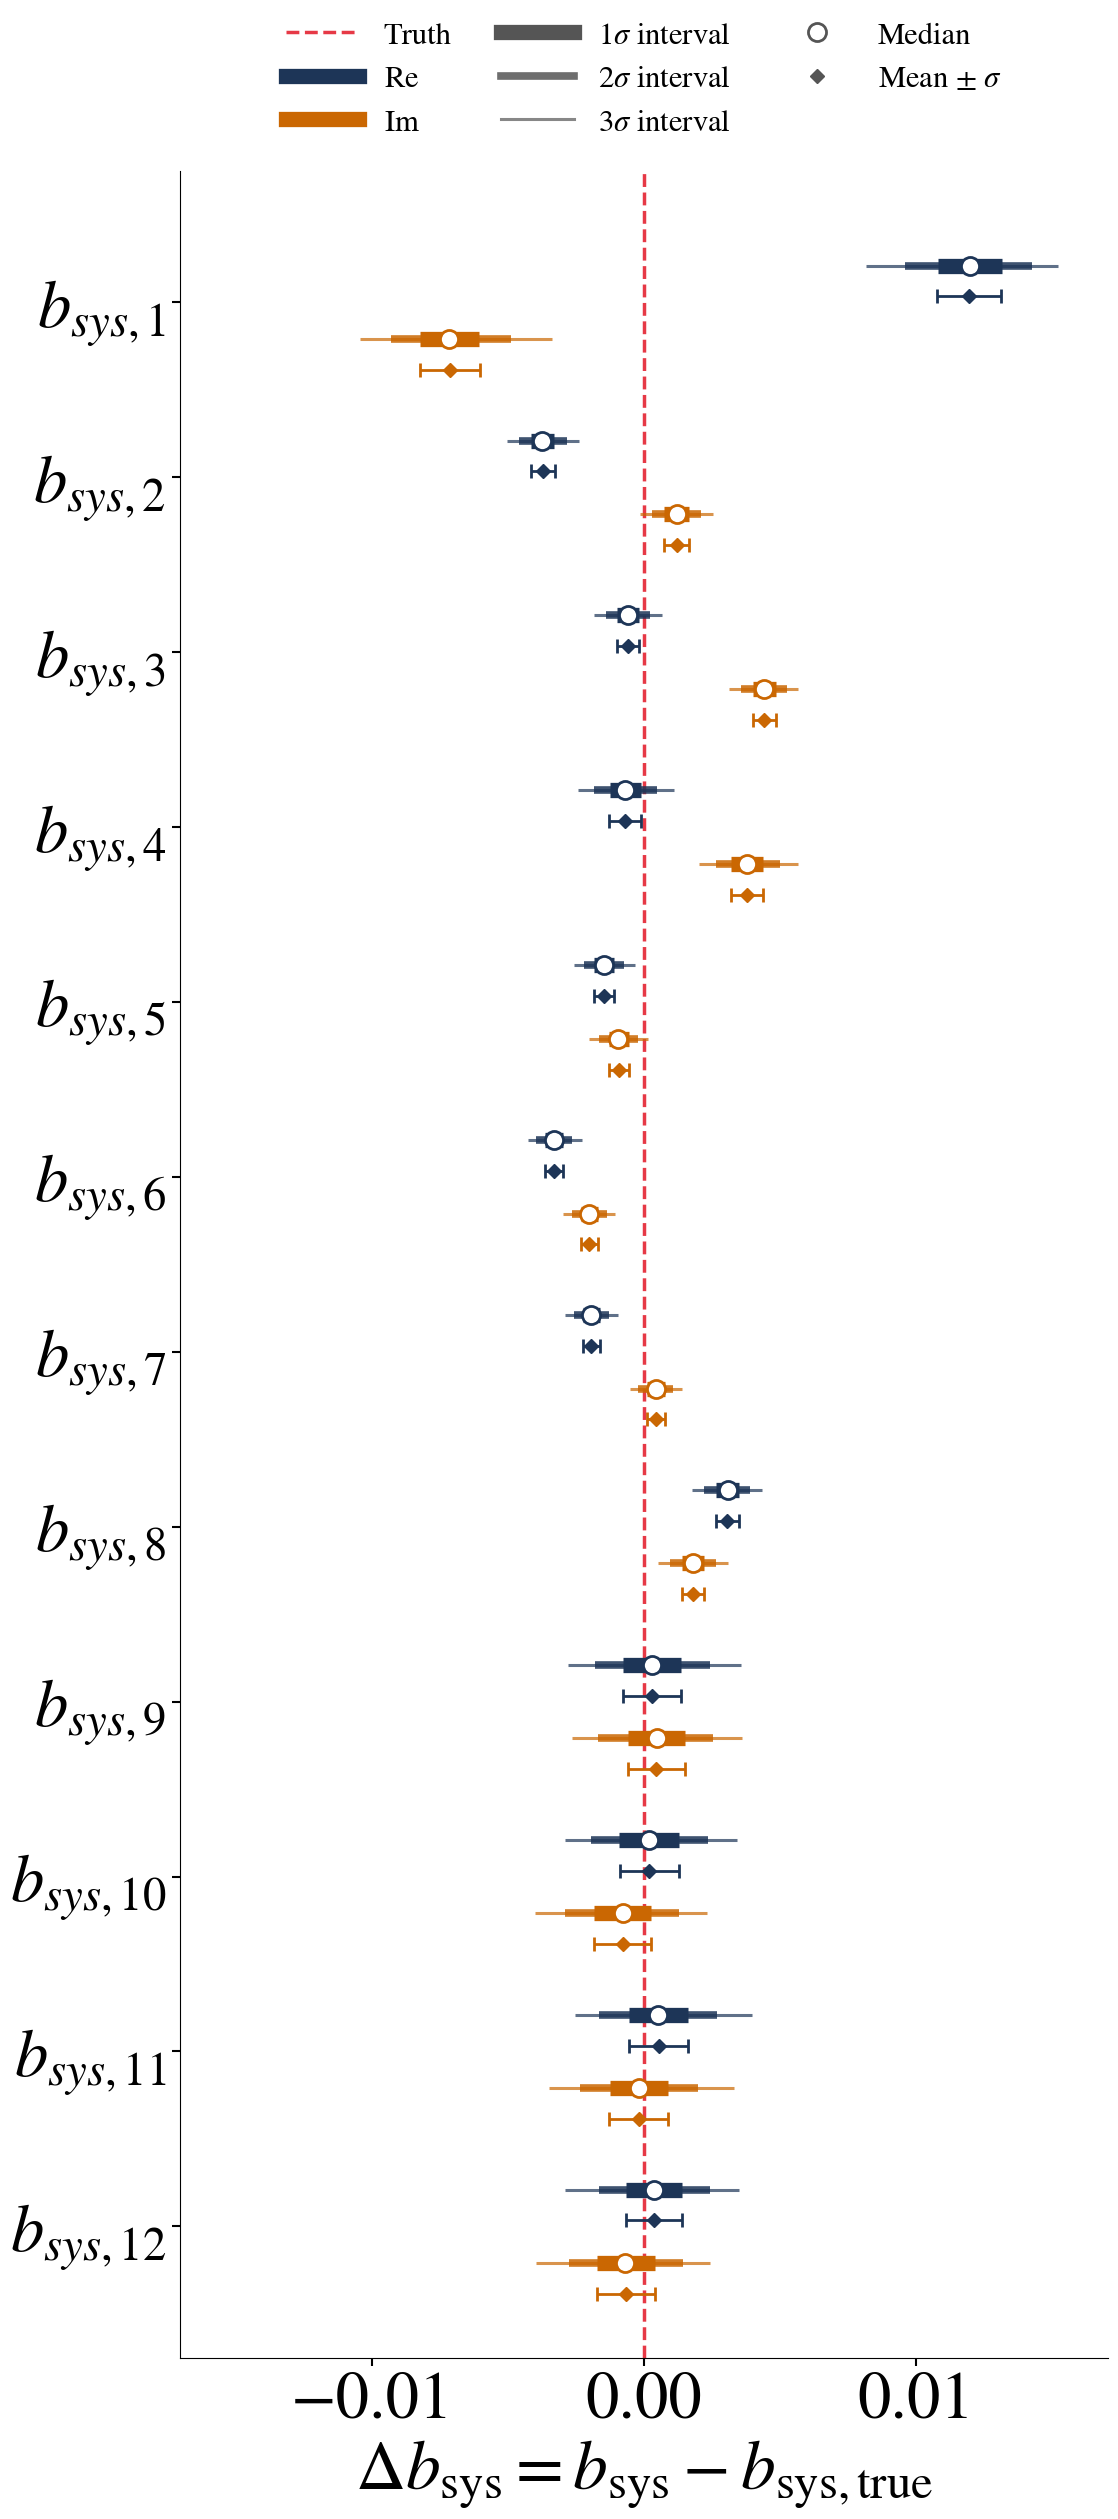

In [33]:
# Same chain and same credible levels as the corner plot above; the complex
# amplitudes are drawn as their real and imaginary parts.
import plot_delta_bsys as pdb
# plt.rcParams['font.size'] = 80
fig, bsys_delta_summaries = pdb.plot_delta_bsys(
    b_sys_gcr[:Niter],                  # complex -> Re and Im point sets
    sys_amps_true,
    labels=[rf'$b_{{sys,{i}}}$' for i in range(1, b_sys_gcr.shape[1] + 1)],
    components=('real', 'imag'),
    burn=0,                             # corner_plot above also uses the whole chain
    nsigma=3,
    units='absolute',                   # 'sigma' divides each row by its own sigma
    colors=colors,
    figsize=(12, 26), 
    xlabel=r'$\Delta b_{\mathrm{sys}} = b_{\mathrm{sys}} - '
                  r'b_{\mathrm{sys}, \mathrm{true}}$'
)


# The numbers, kept off the figure: median, +/- deviations, mean, sigma.
print(pdb.summary_text(bsys_delta_summaries))

plt.savefig(fig_dir + '/bsys_delta_plot.pdf', bbox_inches='tight', dpi=150)

---
# Figure 9: Systematics fractional error

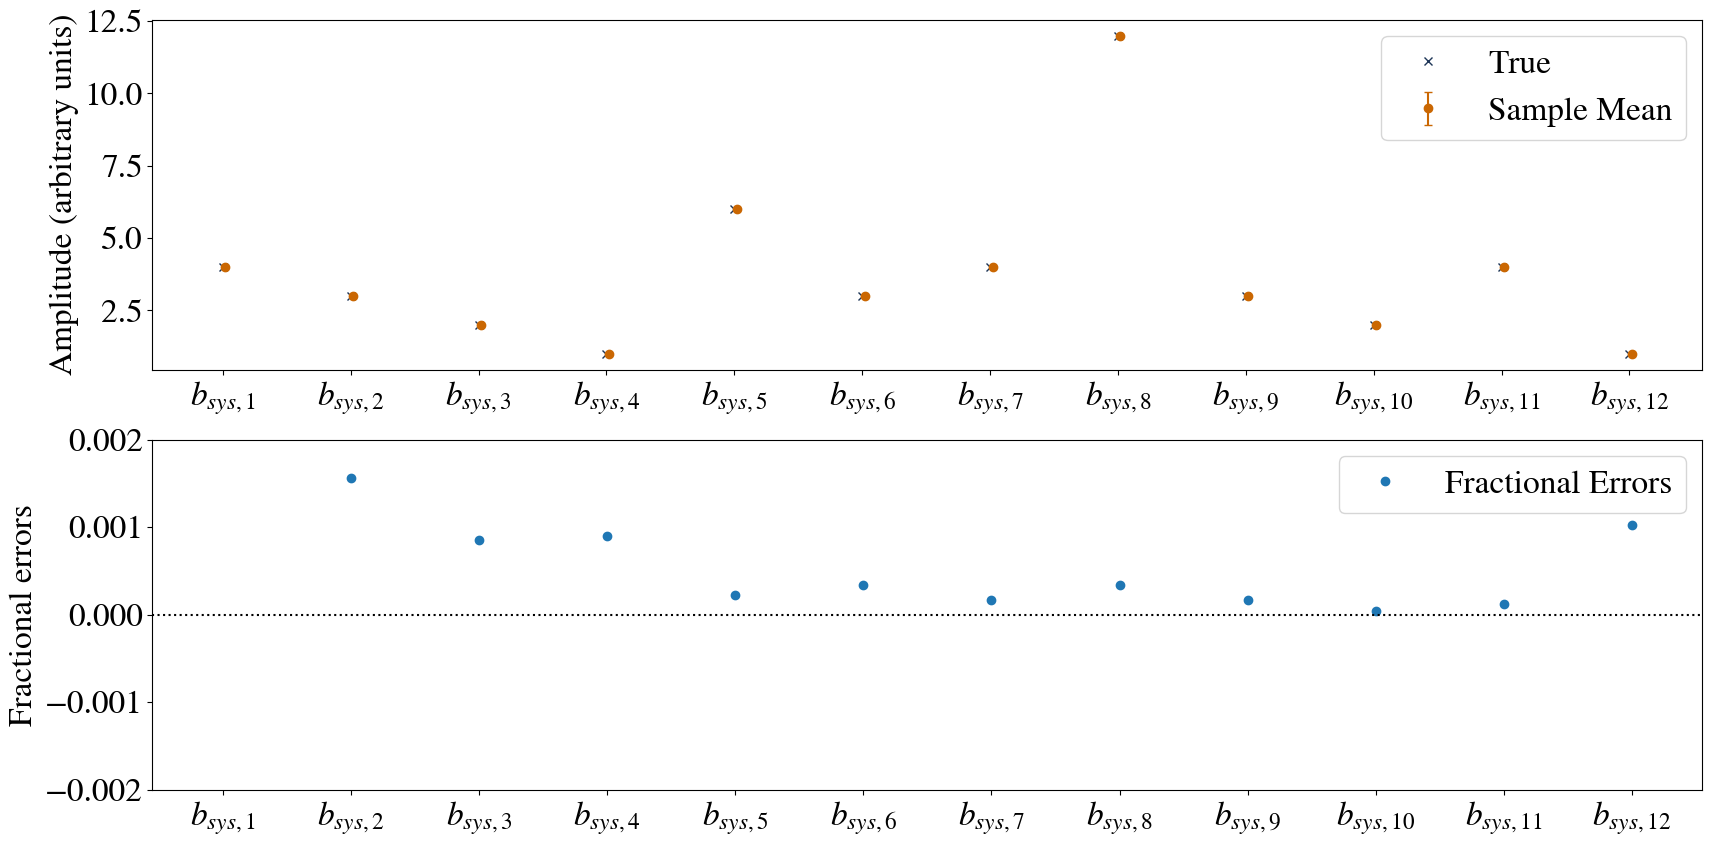

In [58]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

errs = np.vstack((
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
))

ax[0].plot(np.imag(sys_amps_true), 'x', c=colors[0], label='True')
ax[0].errorbar(
    [0.02, 1.02, 2.02, 3.02, 4.02, 5.02, 6.02, 7.02, 8.02, 9.02, 10.02, 11.02], np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o', yerr=errs, label='Sample Mean', capsize=3, c=colors[1],
)
ax[0].set_ylabel('Amplitude (arbitrary units)')
ax[0].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$',r'$b_{sys,5}$', r'$b_{sys,6}$', r'$b_{sys,7}$', r'$b_{sys,8}$',r'$b_{sys,9}$', r'$b_{sys,10}$', r'$b_{sys,11}$', r'$b_{sys,12}$'])
ax[0].legend()

res_mean = np.abs(sys_amps_true - b_sys_gcr.mean(axis=0)) / np.abs(sys_amps_true)
ax[1].plot([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], res_mean, 'o', label='Fractional Errors')
ax[1].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$',r'$b_{sys,5}$', r'$b_{sys,6}$', r'$b_{sys,7}$', r'$b_{sys,8}$',r'$b_{sys,9}$', r'$b_{sys,10}$', r'$b_{sys,11}$', r'$b_{sys,12}$'])
ax[1].axhline(0, c='k', ls='dotted')
ax[1].set_ylabel('Fractional errors')
ax[1].set_ylim(-0.002, 0.002)
ax[1].legend()
# plt.savefig(fig_dir + '/sys_frac_error.pdf', bbox_inches='tight', dpi=300)

---
# Figure 10: Delay power spectrum

Max fractional error: 39.630875785920914


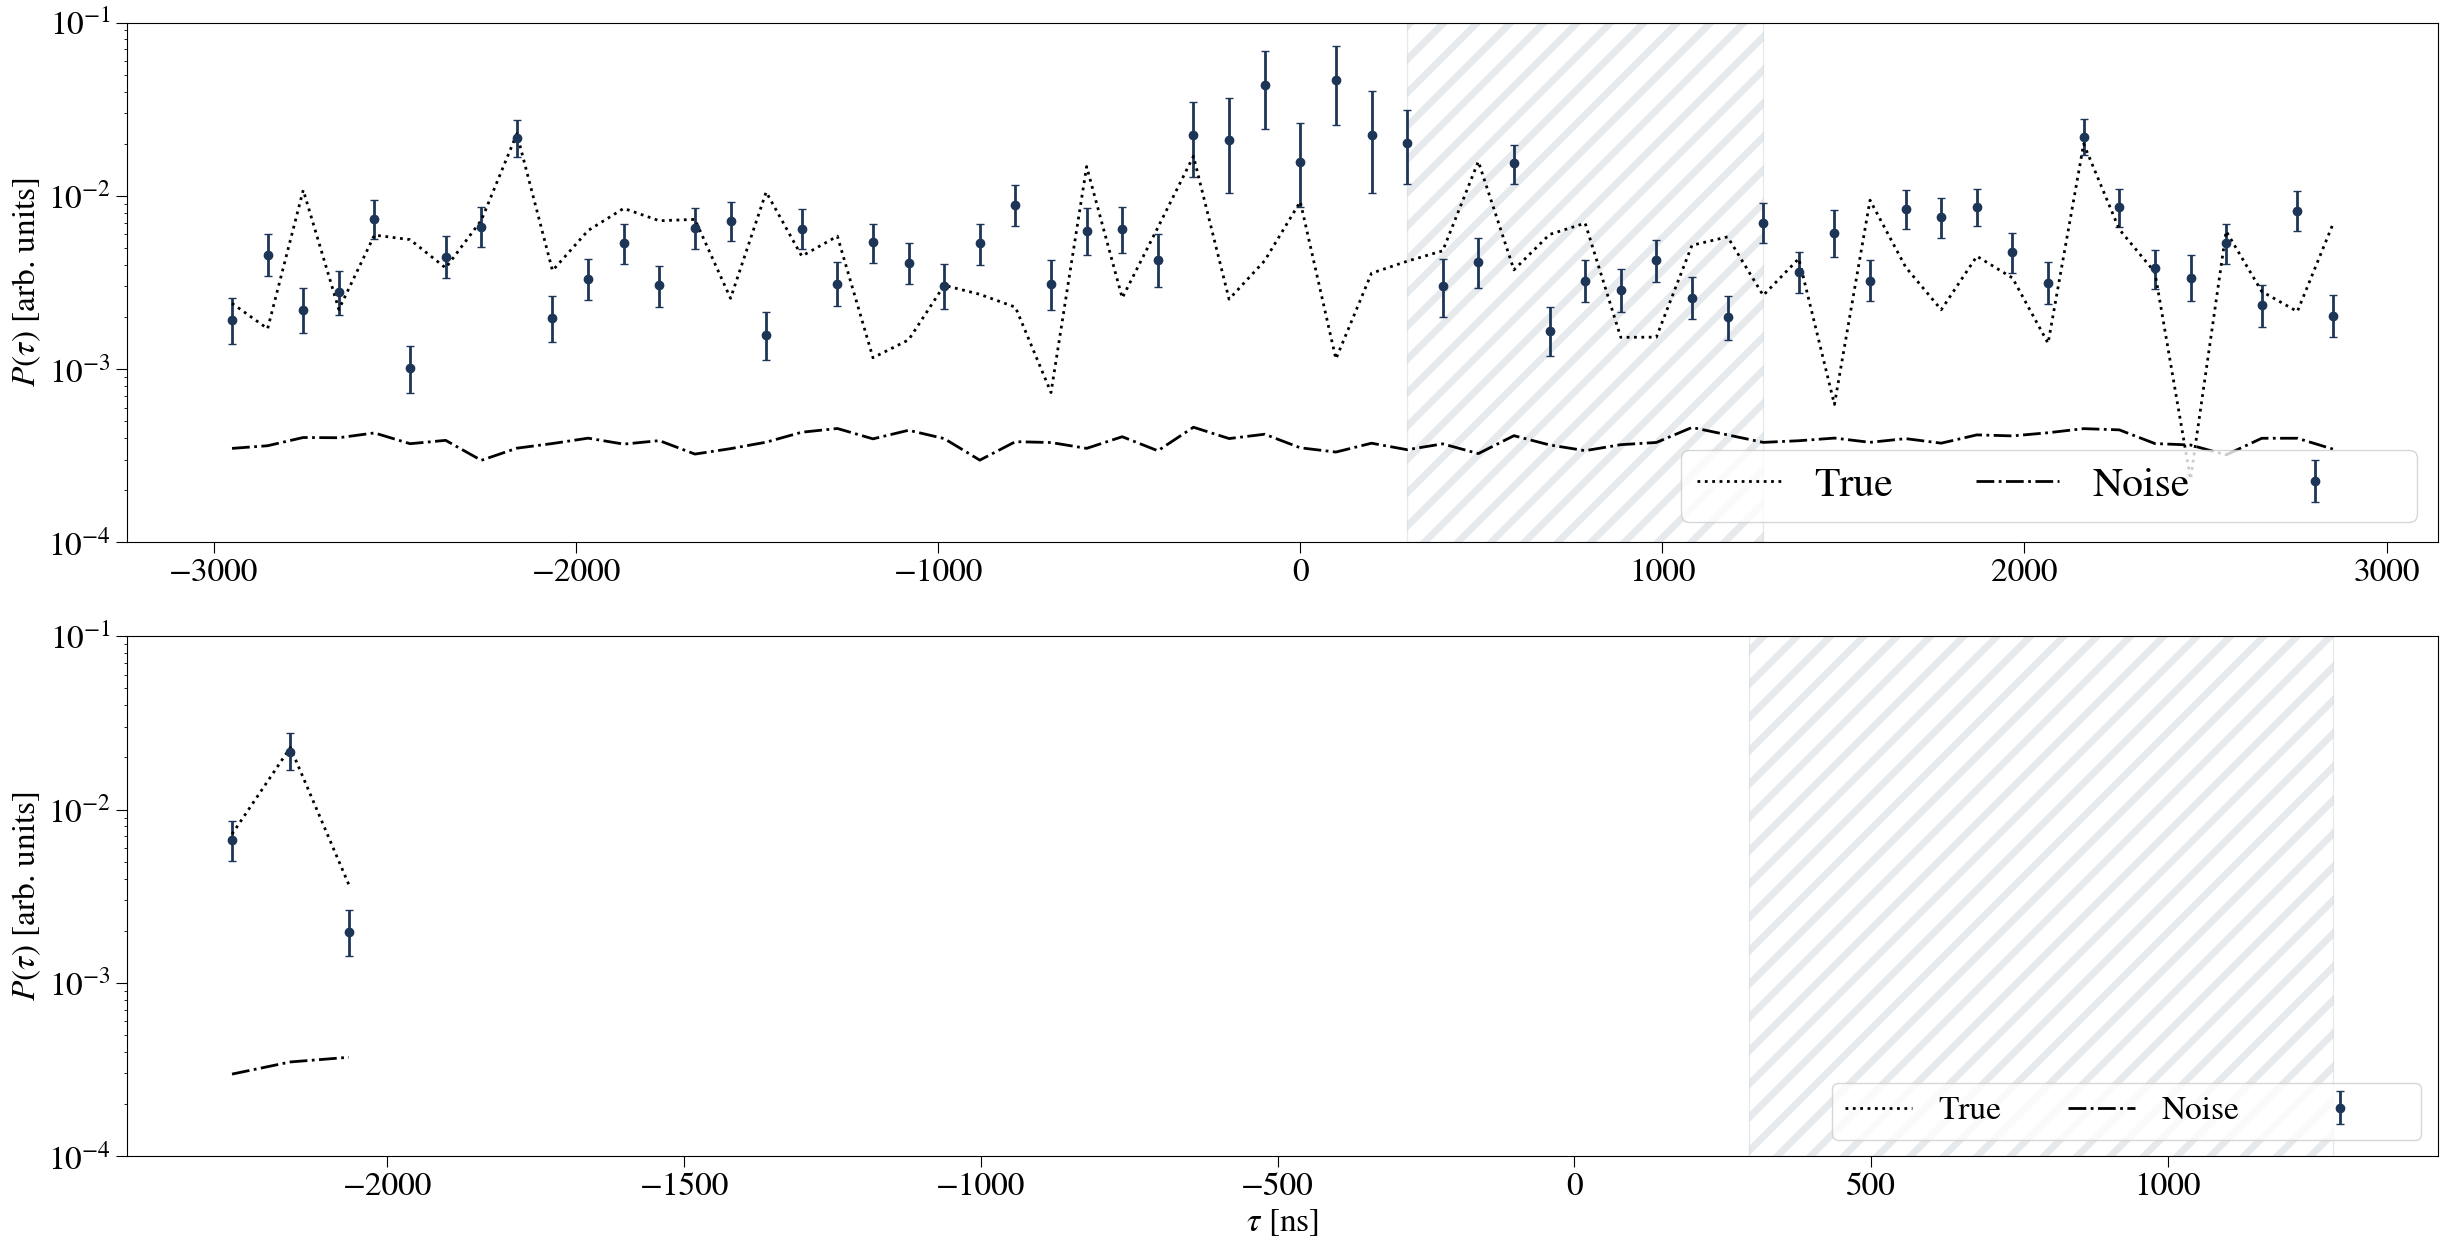

In [59]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

sys_delays = delays[np.unique(dl_ind) + int(Nfreqs / 2)].value

ps_sample_plot = ps_sample[Nburn:Niter]
ln_post_plot   = ln_post[Nburn:Niter]

dps_pwm    = np.average(ps_sample_plot, weights=ln_post_plot, axis=0)
percentile = conf_interval / 2 + 50
dps_ubound = np.percentile(ps_sample_plot, percentile,       axis=0)
dps_lbound = np.percentile(ps_sample_plot, 100 - percentile, axis=0)
dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

ax[0].errorbar(
    delays.value, dps_pwm, yerr=np.abs(dps_err),
    color=colors[0], ls='', marker='o', elinewidth=2, capsize=3, label=case_label,
)

x0, x1 = np.min(sys_delays), np.max(sys_delays)
ax[0].axvspan(x0, x1, facecolor='none', ec=colors[0], hatch='/', hatch_linewidth=5, alpha=0.1, zorder=0.1)
ax[1].axvspan(x0, x1, facecolor='none', ec=colors[0], hatch='/', hatch_linewidth=5, alpha=0.1, zorder=0.1)

zoom = slice(7, 10)
ax[1].errorbar(
    delays[zoom].value, dps_pwm[zoom], yerr=np.abs(dps_err[:, zoom]),
    color=colors[0], ls='', marker='o', elinewidth=2, capsize=3, label=case_label,
)
print('Max fractional error:', max((dps_pwm - eor_pspec_true) / eor_pspec_true))

ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].set_ylim(1e-4, 1e-1)
ax[1].plot(delays[zoom], eor_pspec_true[zoom], 'k:', label='True', lw=2)
ax[1].plot(delays[zoom], n_pspec[zoom], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3)
ax[1].set_yscale('log')

ax[0].plot(delays, eor_pspec_true, 'k:', label='True', lw=2)
ax[0].plot(delays, n_pspec, 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3, fontsize=30)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-1)
ax[0].set_yscale('log')

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()
# plt.savefig(fig_dir + '/multi_dps.pdf', bbox_inches='tight', dpi=300)

---
# Table 1: sampling efficiency of the systematic amplitudes

How much independent information about $b_\mathrm{sys}$ this run actually
bought, per Gibbs iteration.

* $\tau$ (integrated autocorrelation time) — how many iterations the sampler
  needs before it forgets its previous sample. **Lower is better.**
* $N_\mathrm{eff} = N/\tau$ (effective sample size) — how many *independent*
  draws the chain is worth. **Higher is better.** The table colours it green
  above 1000, amber between 400 and 1000, red below 400 (Vehtari et al. 2021:
  posterior means and 95 % intervals need $N_\mathrm{eff} \gtrsim 400$).

Each row is one complex amplitude, so its $\tau$ combines the real and
imaginary parts.  The fold-out under the table has the same table as Markdown
and LaTeX, ready to paste; `.md`, `.tex`, `.csv` and `.html` copies are written
to `fig_dir/tables`.

In [60]:
print("-------ESS TABLES------- \n")
import emcee
b_sys = np.load(result_dir + run_version + '/b-sys.npy')
taus  = emcee.autocorr.integrated_time(b_sys, c=5, tol=50, quiet=True, has_walkers=False)
ess   = Niter / taus
print('\n Taus: {}\nEss:{}\n'.format(taus, ess))
print(min(taus),max(taus),min(ess),max(ess))

-------ESS TABLES------- 


 Taus: [330.50558355  88.29861469  53.91540245  91.17784734  43.07770387
  32.66972286  33.28568168  48.2169299  256.90834745 270.25460921
 227.5664206  286.5755089 ]
Ess:[ 756.41687294 2831.30149743 4636.89388633 2741.89408155 5803.46623704
 7652.34529481 7510.73697023 5184.90083264  973.10968089  925.05360309
 1098.58035884  872.37043024]

32.669722858628575 330.5055835517804 756.4168729416714 7652.345294810824


In [61]:
table1 = tbl.ess_table(
    {f'{case_label} ({run_version})': b_sys_gcr[:Niter]},
    param_names=[f'b_sys,{k + 1}' for k in range(b_sys_gcr.shape[1])],
    title='Table 1 — sampling efficiency of the systematic amplitudes b_sys',
    subtitle=('Integrated autocorrelation time and effective sample size of each '
              'complex systematic amplitude of this run.'),
    name='table1_ess_bsys',
)

Case,Parameter,N samples,τ [samples],ESS,ESS / N,N > 50τ
(caseiv),"b_sys,1","100,000",220.3,454,0.005,yes
(caseiv),"b_sys,2","100,000",73.6,"1,359",0.014,yes
(caseiv),"b_sys,3","100,000",44.1,"2,266",0.023,yes
(caseiv),"b_sys,4","100,000",101.6,984,0.010,yes
(caseiv),"b_sys,5","100,000",32.5,"3,077",0.031,yes
(caseiv),"b_sys,6","100,000",22.6,"4,419",0.044,yes
(caseiv),"b_sys,7","100,000",22.3,"4,484",0.045,yes
(caseiv),"b_sys,8","100,000",54.3,"1,840",0.018,yes
(caseiv),"b_sys,9","100,000",154.2,649,0.006,yes
(caseiv),"b_sys,10","100,000",74.4,"1,344",0.013,yes


---
### Figure T1: $\tau$ and ESS per systematic mode → `ess_tau_bsys.pdf`

Table 1 drawn, so the amplitudes can be compared at a glance.  Left: $\tau$ per
amplitude (log scale, lower is better).  Right: ESS, with the quality bands
shaded — red below 400 (unreliable), amber 400 to 1000 (usable), green above
1000 (comfortable).

Wrote 4 files for 1 tables in /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables
  table1_ess_bsys.{md,tex,csv,html}


['/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.md',
 '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.tex',
 '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.csv',
 '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.html']

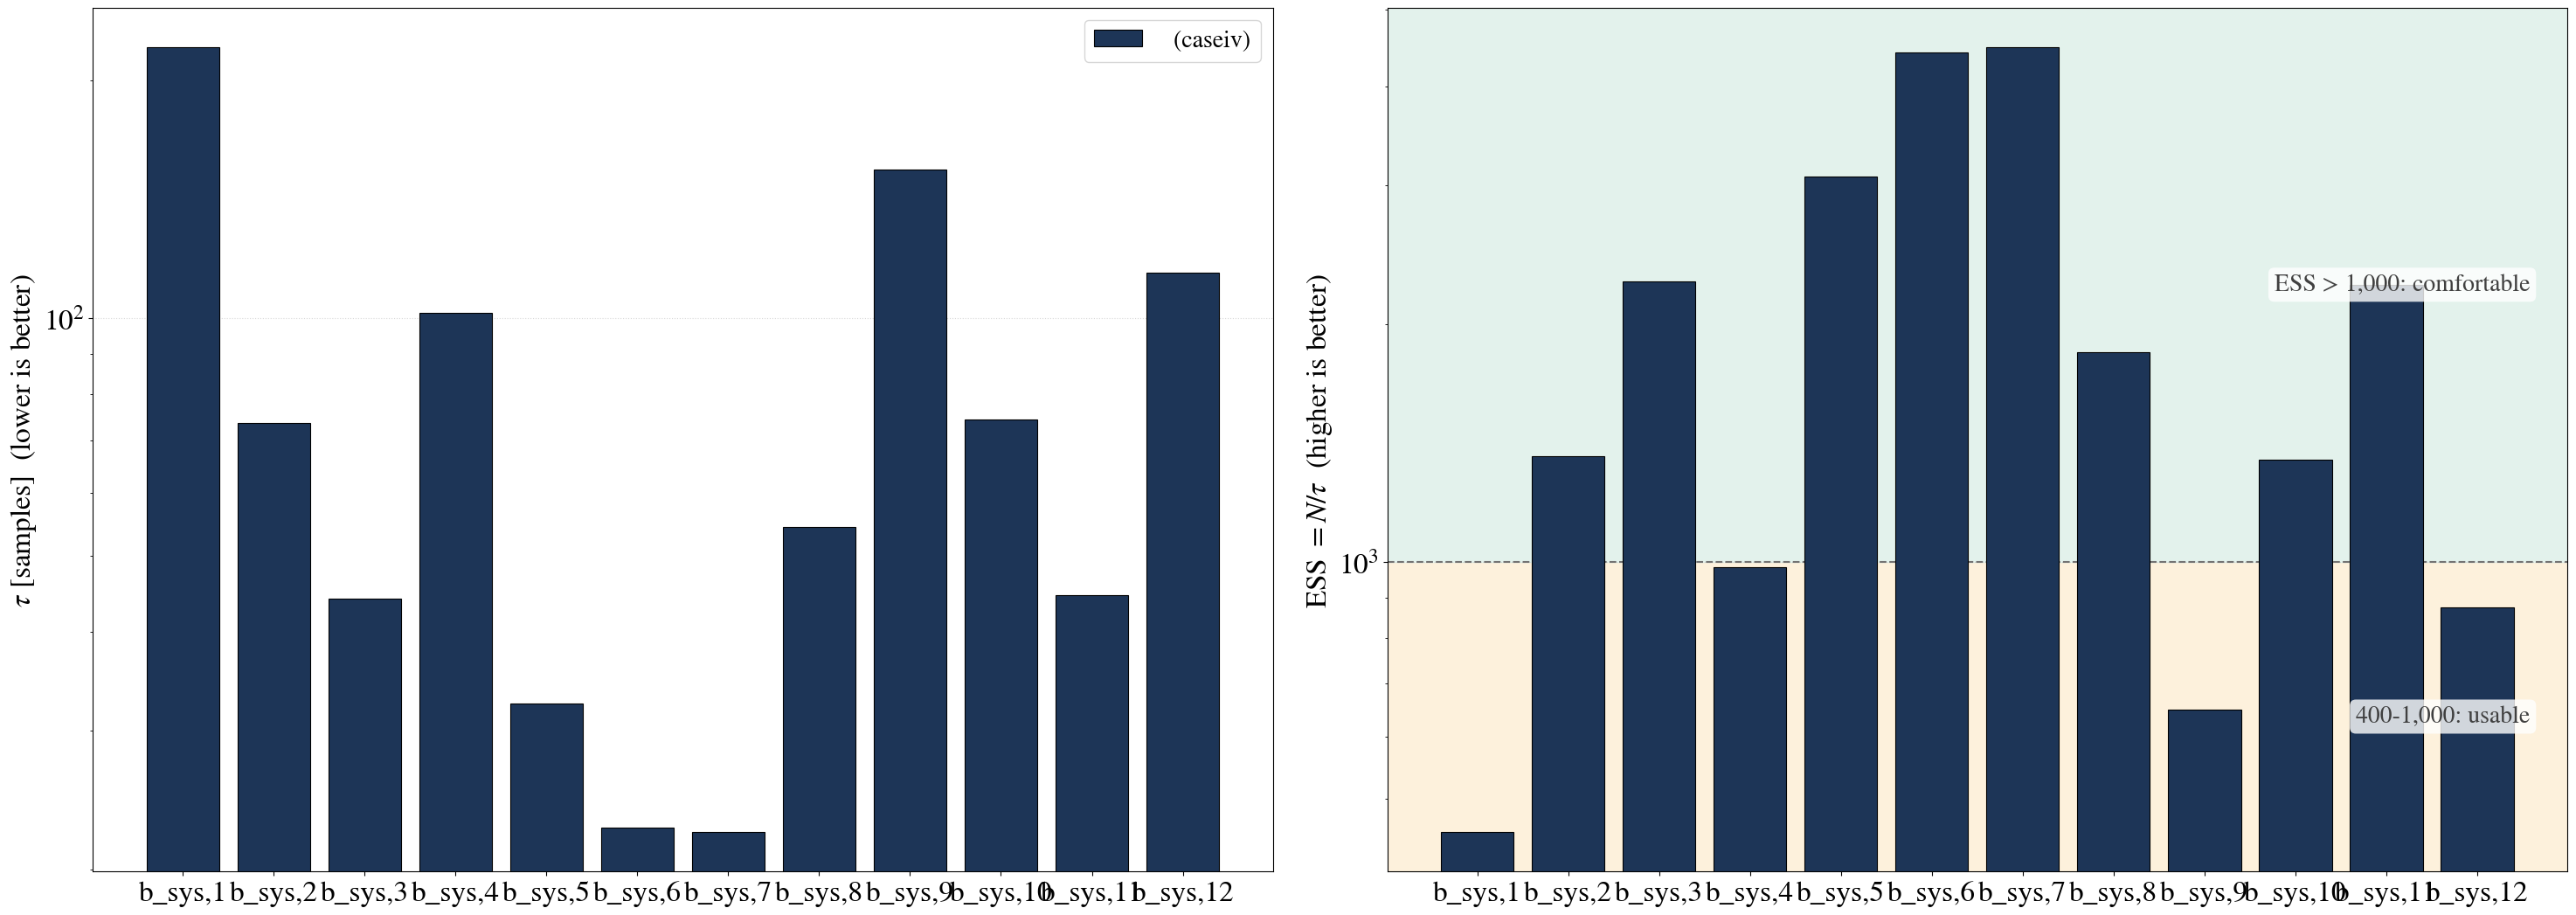

In [62]:
fig = tbl.plot_ess_tau(table1, colors=colors, figsize=(30, 11))
plt.savefig(fig_dir + '/ess_tau_bsys.pdf', bbox_inches='tight', dpi=300)

# Markdown / LaTeX / CSV / HTML copies of the table, ready to send on.
tbl.save_tables(fig_dir + '/tables')


---
# Figure 11: FG–systematics correlation

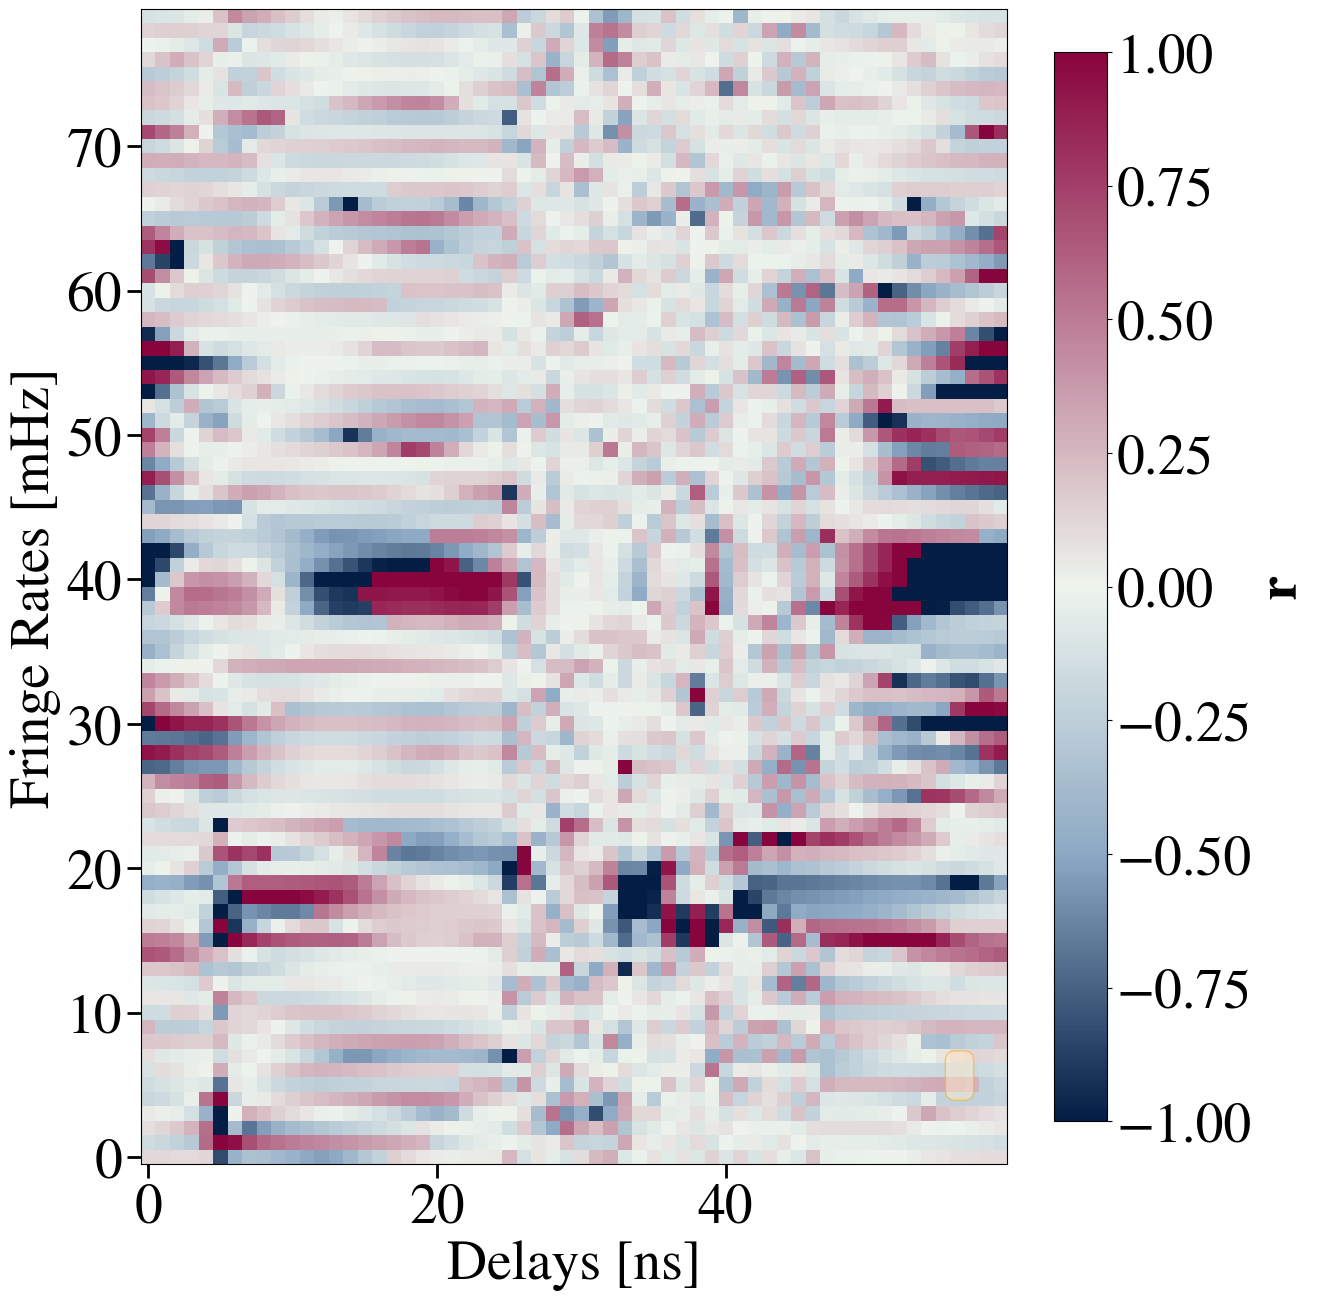

In [63]:
fig, axs = plt.subplots(1, 1, figsize=(15, 15))

im = axs.imshow(corr_map[::-1, :].real, cmap=paper_map, origin='lower', vmin=-1, vmax=1)
axs.text(0.95, 0.07, case_label, bbox=bbox,
         transform=axs.transAxes, horizontalalignment='right')

cbar = plt.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
cbar.set_label(r'$\mathbf{r}$', size=40)
cbar.ax.tick_params(labelsize=40)

axs.set_xlabel('Delays [ns]', fontsize=40)
axs.set_ylabel('Fringe Rates [mHz]', fontsize=40)
axs.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=40)
# axs.set_xticks(xticklocs, labels=xticklabels_dl, rotation=15)
# axs.set_yticks(yticklocs, labels=yticklabels_fr)

# plt.savefig(fig_dir + '/fg_sys_corr.pdf', bbox_inches='tight', dpi=300)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 250000 and the array at index 1 has size 100000

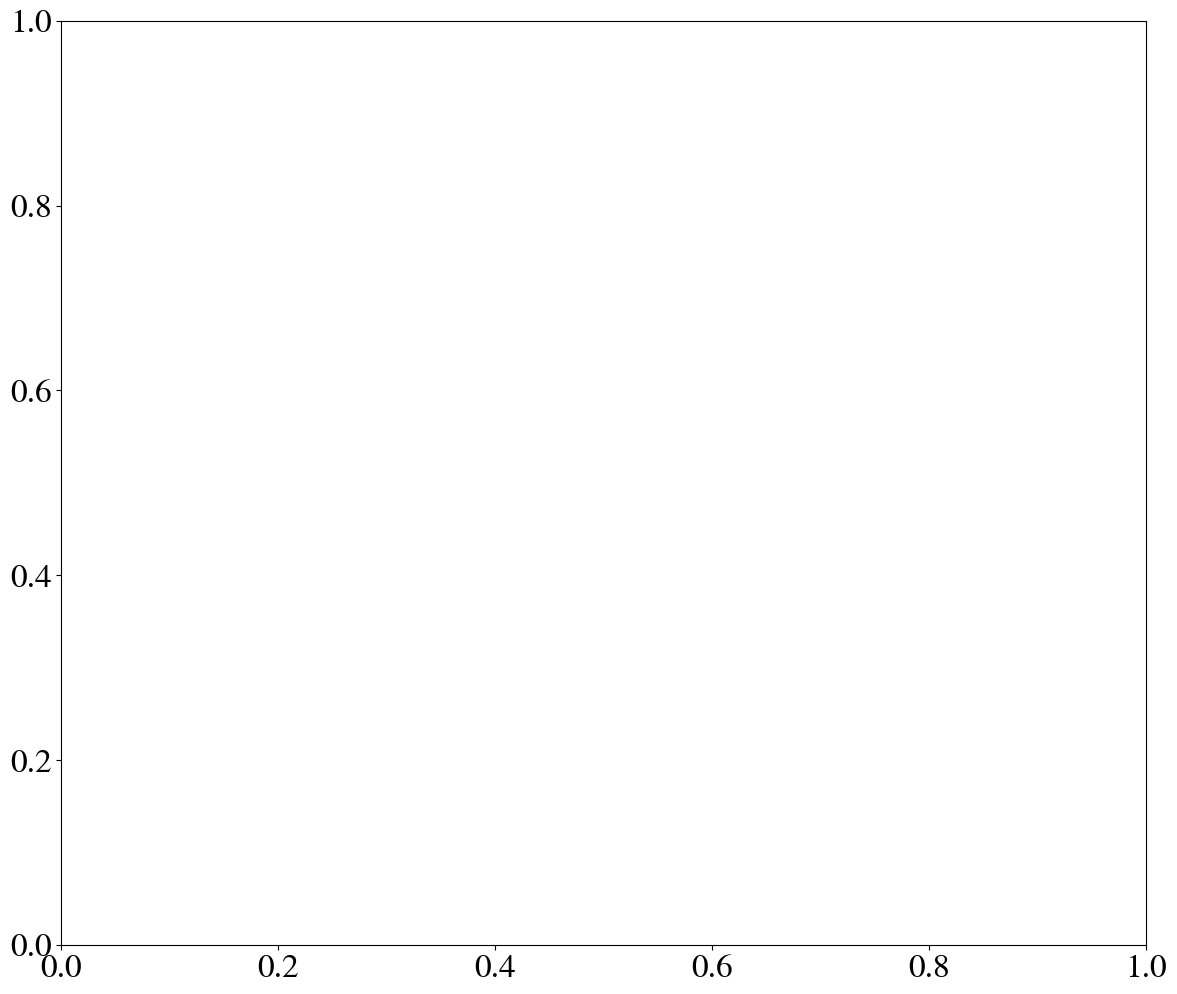

In [64]:
# Single-panel version of Figure 9 (fig:corr) — for the combined systematics case

def plot_correlation_matrix(corr, ax, param_names, param_sizes, fontsize=40, cmap="RdBu"):
    """
    Plot a formatted correlation matrix into a given Axes object.
    (unchanged from the multi-case version)
    """
    im = ax.matshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect="auto", interpolation="none")

    # --- Block dividing lines ---
    boundaries = np.cumsum(param_sizes)[:-1] - 0.5
    for b in boundaries:
        ax.axhline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)
        ax.axvline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)

    # --- Block centre positions for labels ---
    centres = []
    start = 0
    for size in param_sizes:
        centres.append(start + size / 2 - 0.5)
        start += size

    # --- Axis labels ---
    ax.set_xticks(centres)
    ax.set_xticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.set_yticks(centres)
    ax.set_yticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.tick_params(length=0)

    return im


# --- Usage: single case (the combined case) ---
param_names = [r'a_\text{fg}', r'b_\text{sys}']
param_sizes = [10, 2]
combined_case_label = ' '
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
plt.rcParams.update({'font.size': 50})

fg_flat = np.abs(fg_amps_gcr[:Niter, -3, :]).reshape(Niter, -1)
samples_all = np.concatenate([fg_flat, np.abs(b_sys_gcr[:Niter, :])], axis=1)
corr = np.corrcoef(samples_all, rowvar=False)

im = plot_correlation_matrix(
    corr        = corr,
    ax          = ax,
    param_names = param_names,
    param_sizes = param_sizes,
    cmap        = paper_map,
    fontsize    = 50,
)
# ax.text(0.95, 0.07, combined_case_label, bbox=bbox_res,
#          transform=ax.transAxes, horizontalalignment='right')

# --- Colorbar attached directly to the single Axes ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label="Correlation Coefficient", fontsize=50, labelpad=15)
cax.yaxis.label.set_size(50)
cax.tick_params(labelsize=50)

fig.tight_layout()
# plt.savefig(fig_dir + '/multi_corr.pdf', bbox_inches='tight', dpi=300)
print("Combined-case correlation matrix saved")

In [ ]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 34m 14.0s
